In [ ]:
from pathlib import Path

FRAME_NAME = "timestep_3420"
FRAME_ZIP = "/content/timestep_3420.zip"

REPO_DIR = Path("/content/Wheat-3DGS")
DATA_ROOT = Path("/content/data")
FRAME_ROOT = DATA_ROOT / FRAME_NAME
OUTPUT_ROOT = Path("/content/output")

RESOLUTION = 4
ITERATIONS = 15000
TEST_COUNT = 5

# choose output name
EXP_NAME = f"{FRAME_NAME}_baseline_randbg_masked_clean"

print("FRAME_NAME  =", FRAME_NAME)
print("FRAME_ZIP   =", FRAME_ZIP)
print("FRAME_ROOT  =", FRAME_ROOT)
print("EXP_NAME    =", EXP_NAME)

FRAME_NAME  = timestep_3420
FRAME_ZIP   = /content/timestep_3420.zip
FRAME_ROOT  = /content/data/timestep_3420
EXP_NAME    = timestep_3420_baseline_randbg_masked_clean


In [ ]:
import zipfile
import shutil
from pathlib import Path

extract_root = Path("/content/_tmp_extract")
zip_path = Path(FRAME_ZIP)

if extract_root.exists():
    shutil.rmtree(extract_root)
extract_root.mkdir(parents=True, exist_ok=True)

DATA_ROOT.mkdir(parents=True, exist_ok=True)

if FRAME_ROOT.exists():
    shutil.rmtree(FRAME_ROOT)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_root)

print("Top-level extracted contents:")
for p in sorted(extract_root.iterdir()):
    print(" -", p)

candidates = [p for p in extract_root.rglob(FRAME_NAME) if p.is_dir()]
if not candidates:
    raise FileNotFoundError(f"Could not find folder named {FRAME_NAME} inside {FRAME_ZIP}")

src_frame = candidates[0]
shutil.move(str(src_frame), str(FRAME_ROOT))

print("\nFinal dataset root:", FRAME_ROOT)
print("Contents:")
for p in sorted(FRAME_ROOT.iterdir()):
    print(" -", p)

Top-level extracted contents:
 - /content/_tmp_extract/__MACOSX
 - /content/_tmp_extract/timestep_3420

Final dataset root: /content/data/timestep_3420
Contents:
 - /content/data/timestep_3420/images
 - /content/data/timestep_3420/masks
 - /content/data/timestep_3420/sparse


In [ ]:
from pathlib import Path
import shutil
import os

frame_root = FRAME_ROOT

# normalize sparse/0
sparse_root = frame_root / "sparse"
if not sparse_root.exists():
    raise FileNotFoundError("No sparse directory found")

if not (sparse_root / "0").exists():
    zero_dir = sparse_root / "0"
    zero_dir.mkdir(exist_ok=True)
    for p in list(sparse_root.iterdir()):
        if p.name == "0":
            continue
        shutil.move(str(p), str(zero_dir / p.name))
    print("✅ Created sparse/0 and moved files into it")
else:
    print("✅ sparse/0 already exists")

# preserve GT masks as masks_binary_gt
gt_src = frame_root / "masks"
gt_dst = frame_root / "masks_binary_gt"
if gt_src.exists() and not gt_dst.exists():
    shutil.move(str(gt_src), str(gt_dst))
    print("✅ Moved masks_binary -> masks_binary_gt")
elif gt_dst.exists():
    print("✅ masks_binary_gt already exists")
else:
    raise FileNotFoundError("No masks_binary found in dataset")

# create active symlink
active = frame_root / "masks_binary_active"
if active.exists() or active.is_symlink():
    active.unlink() if active.is_symlink() else shutil.rmtree(active)

os.symlink(gt_dst, active, target_is_directory=True)
print("✅ masks_binary_active ->", active.resolve())

✅ sparse/0 already exists
✅ Moved masks_binary -> masks_binary_gt
✅ masks_binary_active -> /content/data/timestep_3420/masks_binary_gt


In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np
import shutil

images_dir = FRAME_ROOT / "images"
ones_dir = FRAME_ROOT / "masks_binary_ones"

if ones_dir.exists():
    shutil.rmtree(ones_dir)
ones_dir.mkdir(parents=True, exist_ok=True)

for img_path in sorted(images_dir.iterdir()):
    if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue
    img = Image.open(img_path)
    ones = np.ones((img.size[1], img.size[0]), dtype=np.uint8) * 255
    Image.fromarray(ones).save(ones_dir / f"{img_path.stem}_mask_ground_truth.png")

print("✅ masks_binary_ones created")

✅ masks_binary_ones created


In [ ]:
%%bash
set -e

rm -rf /content/Wheat-3DGS

git clone https://github.com/zdwww/Wheat-3DGS.git /content/Wheat-3DGS
cd /content/Wheat-3DGS
git submodule sync --recursive
git submodule update --init --recursive

echo "✅ Repo cloned fresh"

Submodule path 'submodules/diff-gaussian-rasterization': checked out '8829d14f814fccdaf840b7b0f3021a616583c0a1'
Submodule path 'submodules/diff-gaussian-rasterization/third_party/glm': checked out '5c46b9c07008ae65cb81ab79cd677ecc1934b903'
Submodule path 'submodules/flashsplat-rasterization': checked out 'b7698d2733fcecef2f2e46febdbf8e93735d2a00'
Submodule path 'submodules/simple-knn': checked out '86710c2d4b46680c02301765dd79e465819c8f19'
✅ Repo cloned fresh


Cloning into '/content/Wheat-3DGS'...
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/ashawkey/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/flashsplat-rasterization' (https://github.com/florinshen/flashsplat-rasterization.git) registered for path 'submodules/flashsplat-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/Wheat-3DGS/submodules/diff-gaussian-rasterization'...
Cloning into '/content/Wheat-3DGS/submodules/flashsplat-rasterization'...
Cloning into '/content/Wheat-3DGS/submodules/simple-knn'...
Submodule 'third_party/glm' (https://github.com/g-truc/glm.git) registered for path 'submodules/diff-gaussian-rasterization/third_party/glm'
Cloning into '/content/Wheat-3DGS/submodules/diff-gaussian-rasterization/third_party/glm'...


In [ ]:
%%bash
set -e

export CUDA_HOME=/usr/local/cuda
export CUDACXX=/usr/local/cuda/bin/nvcc
export PATH=/usr/local/cuda/bin:$PATH
export LD_LIBRARY_PATH=/usr/local/cuda/lib64:$LD_LIBRARY_PATH

python -m pip install -q --upgrade pip
pip install -q plyfile ffmpeg-python lpips ninja cmake open3d

TORCH_LIB=$(python -c "import os, torch; print(os.path.join(os.path.dirname(torch.__file__), 'lib'))")
export LD_LIBRARY_PATH=$TORCH_LIB:$LD_LIBRARY_PATH

cd /content/Wheat-3DGS

CUDA_HOME=/usr/local/cuda CUDACXX=/usr/local/cuda/bin/nvcc \
pip install -v --no-build-isolation -e submodules/simple-knn

CUDA_HOME=/usr/local/cuda CUDACXX=/usr/local/cuda/bin/nvcc \
pip install -v --no-build-isolation -e submodules/diff-gaussian-rasterization

CUDA_HOME=/usr/local/cuda CUDACXX=/usr/local/cuda/bin/nvcc \
pip install -v --no-build-isolation -e submodules/flashsplat-rasterization

echo "✅ Extensions built"

Using pip 26.0.1 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
Obtaining file:///content/Wheat-3DGS/submodules/simple-knn
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for simple_knn (pyproject.toml): started
  Building editable for simple_knn (pyproject.toml): finished with status 'done'
  Created wheel for simple_knn: filename=simple_knn-0.0.0-0.editable-cp312-cp312-linux_x86_64.whl size=5047 sha256=9d8b1d812f3dc1cf807b637e76515b8ac410dac8f2ce289d7737dd602956695d
  Stored in directory: /tmp/pip-ephem-wheel-cache-609lyw1c/wheels/0f/66/53/21a7d1d0c0717f99b8cc4c3a2ac9beb5affef4f88bac5e4893
Successfully built simple_knn
  Attempting uninstall: simple_knn
    Found existing installation: simple_knn 0.0.0
    Uninstalling simple_

  Running command Checking if build backend supports build_editable
  Running command Preparing editable metadata (pyproject.toml)
  running dist_info
  creating /tmp/pip-modern-metadata-94yziymj/simple_knn.egg-info
  writing /tmp/pip-modern-metadata-94yziymj/simple_knn.egg-info/PKG-INFO
  writing dependency_links to /tmp/pip-modern-metadata-94yziymj/simple_knn.egg-info/dependency_links.txt
  writing top-level names to /tmp/pip-modern-metadata-94yziymj/simple_knn.egg-info/top_level.txt
  writing manifest file '/tmp/pip-modern-metadata-94yziymj/simple_knn.egg-info/SOURCES.txt'
  reading manifest file '/tmp/pip-modern-metadata-94yziymj/simple_knn.egg-info/SOURCES.txt'
  adding license file 'LICENSE.md'
  writing manifest file '/tmp/pip-modern-metadata-94yziymj/simple_knn.egg-info/SOURCES.txt'
  creating '/tmp/pip-modern-metadata-94yziymj/simple_knn-0.0.0.dist-info'
  Running command Building editable for simple_knn (pyproject.toml)
  running editable_wheel
  creating /tmp/pip-ephem-wheel

In [ ]:
import os, sys, torch

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

sys.path.insert(0, "/content/Wheat-3DGS")
sys.path.insert(0, "/content/Wheat-3DGS/submodules/simple-knn")
sys.path.insert(0, "/content/Wheat-3DGS/submodules/diff-gaussian-rasterization")
sys.path.insert(0, "/content/Wheat-3DGS/submodules/flashsplat-rasterization")

import simple_knn
import diff_gaussian_rasterization
import flashsplat_rasterization

print("✅ imports OK")

torch: 2.10.0+cu128
cuda available: True
device count: 1
gpu: Tesla T4
✅ imports OK


In [ ]:
from pathlib import Path

# -------------------------
# 1) dataset_readers.py
# -------------------------
path = Path("/content/Wheat-3DGS/scene/dataset_readers.py")
text = path.read_text()

if "alpha_mask_path: str" not in text:
    text = text.replace(
        """class CameraInfo(NamedTuple):
    uid: int
    R: np.array
    T: np.array
    FovY: np.array
    FovX: np.array
    image: np.array
    image_path: str
    image_name: str
    width: int
    height: int
    bbox_path: str
    mask_paths: List[str]
""",
        """class CameraInfo(NamedTuple):
    uid: int
    R: np.array
    T: np.array
    FovY: np.array
    FovX: np.array
    image: np.array
    image_path: str
    image_name: str
    width: int
    height: int
    bbox_path: str
    mask_paths: List[str]
    alpha_mask_path: str
"""
    )

if 'masks_binary_active' not in text:
    text = text.replace(
        """        image_path = os.path.join(images_folder, os.path.basename(extr.name))
        image_name = os.path.basename(image_path).split(".")[0]
        image = Image.open(image_path)
""",
        """        image_path = os.path.join(images_folder, os.path.basename(extr.name))
        image_name = os.path.basename(image_path).split(".")[0]
        image = Image.open(image_path)

        alpha_mask_path = os.path.join(os.path.dirname(images_folder), "masks_binary_active", image_name + "_mask_ground_truth.png")
        alpha_mask_path = os.path.normpath(alpha_mask_path)
        if not os.path.exists(alpha_mask_path):
            alpha_mask_path = None
"""
    )

if "alpha_mask_path=alpha_mask_path" not in text:
    text = text.replace(
        """        cam_info = CameraInfo(uid=uid, R=R, T=T, FovY=FovY, FovX=FovX, image=image,
                              image_path=image_path, image_name=image_name, width=width, height=height,
                              bbox_path=bbox_path, mask_paths=mask_paths)
""",
        """        cam_info = CameraInfo(uid=uid, R=R, T=T, FovY=FovY, FovX=FovX, image=image,
                              image_path=image_path, image_name=image_name, width=width, height=height,
                              bbox_path=bbox_path, mask_paths=mask_paths, alpha_mask_path=alpha_mask_path)
"""
    )

path.write_text(text)

# -------------------------
# 2) camera_utils.py
# -------------------------
path = Path("/content/Wheat-3DGS/utils/camera_utils.py")
text = path.read_text()

if "from PIL import Image" not in text:
    text = text.replace("import numpy as np\n", "import numpy as np\nfrom PIL import Image\n")
if "import torch" not in text:
    text = text.replace("from PIL import Image\n", "from PIL import Image\nimport torch\n")

old_block = """    gt_image = resized_image_rgb[:3, ...]
    loaded_mask = None

    if resized_image_rgb.shape[1] == 4:
        loaded_mask = resized_image_rgb[3:4, ...]

    return Camera(colmap_id=cam_info.uid, R=cam_info.R, T=cam_info.T,
                  FoVx=cam_info.FovX, FoVy=cam_info.FovY,
                  image=gt_image, gt_alpha_mask=loaded_mask,
                  image_name=cam_info.image_name, uid=id, data_device=args.data_device,
                  bbox_path=cam_info.bbox_path, mask_paths=cam_info.mask_paths, resolution=resolution, resolution_scale=scale)
"""

new_block = """    gt_image = resized_image_rgb[:3, ...]
    loaded_mask = None

    if getattr(cam_info, "alpha_mask_path", None) is not None:
        alpha_pil = Image.open(cam_info.alpha_mask_path).convert("L")
        alpha_resized = alpha_pil.resize(resolution, Image.NEAREST)
        alpha_np = np.array(alpha_resized)
        alpha_np = (alpha_np > 128).astype(np.float32)
        loaded_mask = torch.from_numpy(alpha_np).unsqueeze(0)
    elif resized_image_rgb.shape[1] == 4:
        loaded_mask = resized_image_rgb[3:4, ...]

    return Camera(colmap_id=cam_info.uid, R=cam_info.R, T=cam_info.T,
                  FoVx=cam_info.FovX, FoVy=cam_info.FovY,
                  image=gt_image, gt_alpha_mask=loaded_mask,
                  image_name=cam_info.image_name, uid=id, data_device=args.data_device,
                  bbox_path=cam_info.bbox_path, mask_paths=cam_info.mask_paths, resolution=resolution, resolution_scale=scale)
"""

if 'getattr(cam_info, "alpha_mask_path", None)' not in text:
    if old_block not in text:
        raise ValueError("Expected block not found in camera_utils.py")
    text = text.replace(old_block, new_block)

path.write_text(text)

# -------------------------
# 3) cameras.py
# -------------------------
path = Path("/content/Wheat-3DGS/scene/cameras.py")
text = path.read_text()

old_block = """        if gt_alpha_mask is not None:
            self.original_image *= gt_alpha_mask.to(self.data_device)
        else:
            self.original_image *= torch.ones((1, self.image_height, self.image_width), device=self.data_device)
"""

new_block = """        if gt_alpha_mask is not None:
            self.gt_alpha_mask = gt_alpha_mask.to(self.data_device)
        else:
            self.gt_alpha_mask = torch.ones((1, self.image_height, self.image_width), device=self.data_device)

        self.original_image *= self.gt_alpha_mask
"""

if "self.gt_alpha_mask" not in text:
    text = text.replace(old_block, new_block)

path.write_text(text)

print("✅ Repo patched for plant-only GT masking")

ValueError: Expected block not found in camera_utils.py

In [ ]:
from pathlib import Path
import re

path = Path("/content/Wheat-3DGS/utils/camera_utils.py")
text = path.read_text()

# ensure imports exist
if "from PIL import Image" not in text:
    text = text.replace("import numpy as np\n", "import numpy as np\nfrom PIL import Image\n")
if "import torch" not in text:
    if "from PIL import Image\n" in text:
        text = text.replace("from PIL import Image\n", "from PIL import Image\nimport torch\n")
    else:
        text = text.replace("import numpy as np\n", "import numpy as np\nimport torch\n")

# replace the loadCam tail robustly
pattern = re.compile(
    r"gt_image\s*=\s*resized_image_rgb\[:3,\s*\.\.\.\]\s*.*?return Camera\(",
    re.DOTALL
)

match = pattern.search(text)
if not match:
    print(text[:4000])
    raise ValueError("Could not find the gt_image / return Camera block in camera_utils.py")

replacement = """gt_image = resized_image_rgb[:3, ...]
    loaded_mask = None

    if getattr(cam_info, "alpha_mask_path", None) is not None:
        alpha_pil = Image.open(cam_info.alpha_mask_path).convert("L")
        alpha_resized = alpha_pil.resize(resolution, Image.NEAREST)
        alpha_np = np.array(alpha_resized)
        alpha_np = (alpha_np > 128).astype(np.float32)
        loaded_mask = torch.from_numpy(alpha_np).unsqueeze(0)
    elif resized_image_rgb.shape[1] == 4:
        loaded_mask = resized_image_rgb[3:4, ...]

    return Camera("""

text = pattern.sub(replacement, text, count=1)
path.write_text(text)

print("✅ camera_utils.py patched")

✅ camera_utils.py patched


In [ ]:
# -------------------------
# 3) cameras.py
# -------------------------
path = Path("/content/Wheat-3DGS/scene/cameras.py")
text = path.read_text()

old_block = """        if gt_alpha_mask is not None:
            self.original_image *= gt_alpha_mask.to(self.data_device)
        else:
            self.original_image *= torch.ones((1, self.image_height, self.image_width), device=self.data_device)
"""

new_block = """        if gt_alpha_mask is not None:
            self.gt_alpha_mask = gt_alpha_mask.to(self.data_device)
        else:
            self.gt_alpha_mask = torch.ones((1, self.image_height, self.image_width), device=self.data_device)

        self.original_image *= self.gt_alpha_mask
"""

if "self.gt_alpha_mask" not in text:
    text = text.replace(old_block, new_block)

path.write_text(text)

print("✅ Repo patched for plant-only GT masking")

✅ Repo patched for plant-only GT masking


In [ ]:
from pathlib import Path

path = Path("/content/Wheat-3DGS/scene/dataset_readers.py")
with open(path, "r") as f:
    lines = f.readlines()

start = None
end = None
for i, line in enumerate(lines):
    if "if eval:" in line and start is None:
        start = i
    if start is not None and "nerf_normalization = getNerfppNorm(train_cam_infos)" in line:
        end = i
        break

if start is None or end is None:
    raise RuntimeError("Could not find eval split block in dataset_readers.py")

new_block = [
    "    if eval:\n",
    f"        test_count = {TEST_COUNT}\n",
    "        train_cam_infos = cam_infos[:-test_count]\n",
    "        test_cam_infos = cam_infos[-test_count:]\n",
    "        print(f\"Train Cam list with {len(train_cam_infos)} cams: {[cam.image_name for cam in train_cam_infos]}\")\n",
    "        print(f\"Test Cam list with {len(test_cam_infos)} cams: {[cam.image_name for cam in test_cam_infos]}\")\n",
    "    else:\n",
    "        train_cam_infos = cam_infos\n",
    "        test_cam_infos = []\n",
]

lines = lines[:start] + new_block + lines[end:]
path.write_text("".join(lines))

print("✅ Deterministic train/test split patched")

✅ Deterministic train/test split patched


In [ ]:
!grep -n "masks_binary_active" /content/Wheat-3DGS/scene/dataset_readers.py
!grep -n "alpha_mask_path" /content/Wheat-3DGS/scene/dataset_readers.py
!grep -n 'getattr(cam_info, "alpha_mask_path", None)' /content/Wheat-3DGS/utils/camera_utils.py
!grep -n "alpha_resized" /content/Wheat-3DGS/utils/camera_utils.py
!grep -n "self.gt_alpha_mask" /content/Wheat-3DGS/scene/cameras.py
!grep -n "self.original_image \\*= self.gt_alpha_mask" /content/Wheat-3DGS/scene/cameras.py

107:        alpha_mask_path = os.path.join(os.path.dirname(images_folder), "masks_binary_active", image_name + "_mask_ground_truth.png")
42:    alpha_mask_path: str
107:        alpha_mask_path = os.path.join(os.path.dirname(images_folder), "masks_binary_active", image_name + "_mask_ground_truth.png")
108:        alpha_mask_path = os.path.normpath(alpha_mask_path)
109:        if not os.path.exists(alpha_mask_path):
110:            alpha_mask_path = None
127:                              bbox_path=bbox_path, mask_paths=mask_paths, alpha_mask_path=alpha_mask_path)
49:    if getattr(cam_info, "alpha_mask_path", None) is not None:
51:        alpha_resized = alpha_pil.resize(resolution, Image.NEAREST)
52:        alpha_np = np.array(alpha_resized)
46:            self.gt_alpha_mask = gt_alpha_mask.to(self.data_device)
48:            self.gt_alpha_mask = torch.ones((1, self.image_height, self.image_width), device=self.data_device)
50:        self.original_image *= self.gt_alpha_mask
50:        

image: GX010014_20250917_100302_3422.jpg
mask: GX010014_20250917_100302_3422_mask_sam3.png
foreground pixels: 466722
total pixels: 15768510


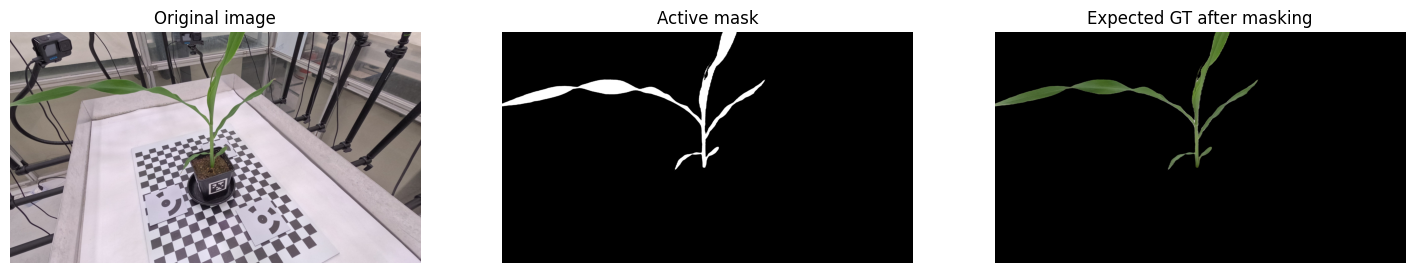

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

images_dir = FRAME_ROOT / "images"
active_masks_dir = FRAME_ROOT / "masks_binary_active"

img_candidates = sorted(images_dir.glob("*.jpg")) + sorted(images_dir.glob("*.png"))
img_path = img_candidates[0]
mask_path = active_masks_dir / f"{img_path.stem}_mask_sam3.png"

img = np.array(Image.open(img_path).convert("RGB"))
mask = np.array(Image.open(mask_path).convert("L")) > 127

masked_img = img.copy()
masked_img[~mask] = 0

print("image:", img_path.name)
print("mask:", mask_path.name)
print("foreground pixels:", int(mask.sum()))
print("total pixels:", int(mask.size))

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(img)
axs[0].set_title("Original image")
axs[0].axis("off")

axs[1].imshow(mask, cmap="gray")
axs[1].set_title("Active mask")
axs[1].axis("off")

axs[2].imshow(masked_img)
axs[2].set_title("Expected GT after masking")
axs[2].axis("off")

plt.show()

In [ ]:
from pathlib import Path

Path("/content/output/tmp_mask_debug").mkdir(parents=True, exist_ok=True)
print("✅ Created debug model directory")

✅ Created debug model directory


In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

FRAME_ROOT = Path("/content/data/timestep_3420")   # change if needed
image_stem = "GX010014_20250917_100302_3422"

mask_path = FRAME_ROOT / "masks_binary_active" / f"{image_stem}_mask_sam3.png"
print("mask_path:", mask_path)
print("exists:", mask_path.exists())

if mask_path.exists():
    mask = np.array(Image.open(mask_path).convert("L"))
    print("shape:", mask.shape)
    print("unique values:", np.unique(mask)[:20])
    print("foreground pixels:", int((mask > 127).sum()))
    print("total pixels:", mask.size)

mask_path: /content/data/timestep_3420/masks_binary_active/GX010014_20250917_100302_3422_mask_sam3.png
exists: True
shape: (2978, 5295)
unique values: [  0 255]
foreground pixels: 466722
total pixels: 15768510


In [ ]:
from pathlib import Path
import shutil

FRAME_ROOT = Path("/content/data/timestep_3420")   # change if needed
active_dir = FRAME_ROOT / "masks_binary_active"

count = 0
for sam3_path in active_dir.glob("*_mask_sam3.png"):
    gt_path = active_dir / sam3_path.name.replace("_mask_sam3.png", "_mask_ground_truth.png")
    if not gt_path.exists():
        shutil.copy2(sam3_path, gt_path)
        count += 1

print(f"✅ Created {count} _mask_ground_truth.png copies in masks_binary_active")

✅ Created 22 _mask_ground_truth.png copies in masks_binary_active


In [ ]:
from pathlib import Path
import shutil

FRAME_ROOT = Path("/content/data/timestep_3420")   # change if needed
gt_dir = FRAME_ROOT / "masks_binary_gt"

count = 0
for sam3_path in gt_dir.glob("*_mask_sam3.png"):
    gt_path = gt_dir / sam3_path.name.replace("_mask_sam3.png", "_mask_ground_truth.png")
    if not gt_path.exists():
        shutil.copy2(sam3_path, gt_path)
        count += 1

print(f"✅ Created {count} _mask_ground_truth.png copies in masks_binary_gt")

✅ Created 0 _mask_ground_truth.png copies in masks_binary_gt


In [ ]:
from pathlib import Path
import shutil

FRAME_ROOT = Path("/content/data/timestep_timestep_3420")   # change if needed
active_dir = FRAME_ROOT / "masks_binary_active"

count = 0
for sam3_path in active_dir.glob("*_mask_sam3.png"):
    gt_name = sam3_path.name.replace("_mask_sam3.png", "_mask_ground_truth.png")
    gt_path = active_dir / gt_name

    if not gt_path.exists():
        shutil.copy2(sam3_path, gt_path)
        count += 1

print(f"✅ Created {count} _mask_ground_truth.png copies from SAM3 masks")

✅ Created 0 _mask_ground_truth.png copies from SAM3 masks


In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

FRAME_ROOT = Path("/content/data/timestep_3420")
image_stem = "GX010014_20250917_100302_3422"

mask_path = FRAME_ROOT / "masks_binary_active" / f"{image_stem}_mask_ground_truth.png"
print("mask_path:", mask_path)
print("exists:", mask_path.exists())

if mask_path.exists():
    mask = np.array(Image.open(mask_path).convert("L"))
    print("shape:", mask.shape)
    print("unique values:", np.unique(mask))
    print("foreground pixels:", int((mask > 127).sum()))
    print("total pixels:", mask.size)

mask_path: /content/data/timestep_3420/masks_binary_active/GX010014_20250917_100302_3422_mask_ground_truth.png
exists: True
shape: (2978, 5295)
unique values: [  0 255]
foreground pixels: 466722
total pixels: 15768510


In [ ]:
import sys
from pathlib import Path
from argparse import ArgumentParser
import torch

REPO_DIR = Path("/content/Wheat-3DGS")
FRAME_ROOT = Path("/content/data/timestep_3420")

sys.path.insert(0, str(REPO_DIR))

from arguments import ModelParams
from scene import Scene
from scene.gaussian_model import GaussianModel

tmp_model = Path("/content/output/tmp_mask_debug")
tmp_model.mkdir(parents=True, exist_ok=True)

parser = ArgumentParser()
model = ModelParams(parser, sentinel=True)
args = parser.parse_args([])

args.source_path = str(FRAME_ROOT)
args.model_path = str(tmp_model)
args.images = "images"
args.eval = True
args.resolution = 4
args.data_device = "cuda" if torch.cuda.is_available() else "cpu"
args.white_background = False

gaussians = GaussianModel(3)
scene = Scene(args, gaussians, load_iteration=None, shuffle=False)

print("✅ Scene loaded")

No directory of saved bounding boxes found!
No directory of saved segmentation masks found!
Reading camera 22/22
Train Cam list with 17 cams: ['GX010014_20250917_100302_3422', 'GX010035_20250917_100302_3422', 'GX010051_20250917_100302_3422', 'GX010056_20250917_100302_3422', 'GX010063_20250917_100302_3422', 'GX010067_20250917_100302_3422', 'GX010073_20250917_100302_3422', 'GX010074_20250917_100302_3422', 'GX010075_20250917_100302_3422', 'GX010083_20250917_100302_3422', 'GX010086_20250917_100302_3422', 'GX010094_20250917_100302_3422', 'GX010107_20250917_100302_3422', 'GX010132_20250917_100302_3422', 'GX010139_20250917_100302_3422', 'GX010146_20250917_100302_3422', 'GX010153_20250917_100302_3422']
Test Cam list with 5 cams: ['GX010161_20250917_100303_3422', 'GX010173_20250917_100302_3422', 'GX010213_20250917_100302_3422', 'GX010284_20250917_100302_3422', 'GX010324_20250917_100302_3422']
Converting point3d.bin to .ply, will happen only the first time you open the scene.
Cameras extent: 0.5

In [ ]:
import sys
from pathlib import Path
import torch
import numpy as np

sys.path.insert(0, "/content/Wheat-3DGS")

from arguments import ModelParams
from scene import Scene
from gaussian_renderer import GaussianModel
from argparse import ArgumentParser

scene_path = "/content/data/timestep_3420"

parser = ArgumentParser()
model = ModelParams(parser, sentinel=True)
args = parser.parse_args([])

args.source_path = scene_path
args.model_path = "/content/output/tmp_mask_debug"
args.images = "images"
args.eval = True
args.resolution = 4
args.data_device = "cuda" if torch.cuda.is_available() else "cpu"
args.white_background = False

gaussians = GaussianModel(3)
scene = Scene(args, gaussians, load_iteration=None, shuffle=False)

cam = scene.getTrainCameras()[0]

img = cam.original_image.detach().cpu().numpy()
mask = cam.gt_alpha_mask.detach().cpu().numpy()

print("original_image shape:", img.shape)
print("gt_alpha_mask shape:", mask.shape)

black_pixels = np.sum(np.all(np.transpose(img, (1,2,0)) == 0, axis=2))
total_pixels = img.shape[1] * img.shape[2]
foreground_pixels = int(mask.sum())

print("pure black pixels in cam.original_image:", int(black_pixels))
print("total pixels:", int(total_pixels))
print("foreground pixels in gt_alpha_mask:", foreground_pixels)
print("mask unique values:", np.unique(mask))

No directory of saved bounding boxes found!
No directory of saved segmentation masks found!
Reading camera 22/22
Train Cam list with 17 cams: ['GX010014_20250917_100302_3422', 'GX010035_20250917_100302_3422', 'GX010051_20250917_100302_3422', 'GX010056_20250917_100302_3422', 'GX010063_20250917_100302_3422', 'GX010067_20250917_100302_3422', 'GX010073_20250917_100302_3422', 'GX010074_20250917_100302_3422', 'GX010075_20250917_100302_3422', 'GX010083_20250917_100302_3422', 'GX010086_20250917_100302_3422', 'GX010094_20250917_100302_3422', 'GX010107_20250917_100302_3422', 'GX010132_20250917_100302_3422', 'GX010139_20250917_100302_3422', 'GX010146_20250917_100302_3422', 'GX010153_20250917_100302_3422']
Test Cam list with 5 cams: ['GX010161_20250917_100303_3422', 'GX010173_20250917_100302_3422', 'GX010213_20250917_100302_3422', 'GX010284_20250917_100302_3422', 'GX010324_20250917_100302_3422']
Cameras extent: 0.5521054530520436
Loading Training Cameras
Loading Test Cameras
Number of points at in

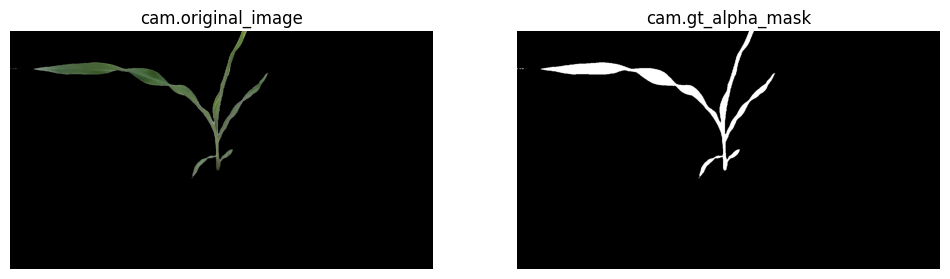

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img_np = np.transpose(img, (1,2,0))
mask_np = mask[0]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(img_np)
axs[0].set_title("cam.original_image")
axs[0].axis("off")

axs[1].imshow(mask_np, cmap="gray")
axs[1].set_title("cam.gt_alpha_mask")
axs[1].axis("off")

plt.show()

In [ ]:
%%bash -s "/content/output/timestep_3420"
set -e

MODEL_DIR="$1"

cd /content/Wheat-3DGS

export CUDA_HOME=/usr/local/cuda
export PATH=$CUDA_HOME/bin:$PATH
export LD_LIBRARY_PATH=$CUDA_HOME/lib64:$LD_LIBRARY_PATH

TORCH_LIB=$(python -c "import os, torch; print(os.path.join(os.path.dirname(torch.__file__), 'lib'))")
export LD_LIBRARY_PATH=$TORCH_LIB:$LD_LIBRARY_PATH

export PYTHONPATH=/content/Wheat-3DGS:/content/Wheat-3DGS/submodules/simple-knn:/content/Wheat-3DGS/submodules/diff-gaussian-rasterization:/content/Wheat-3DGS/submodules/flashsplat-rasterization:$PYTHONPATH

export WANDB_MODE=disabled
export WANDB_DISABLED=true

SCENE="/content/data/timestep_3420"
MODEL="$MODEL_DIR"

rm -rf "$MODEL"

python -u train_vanilla_3dgs.py \
  -s "$SCENE" \
  -m "$MODEL" \
  --resolution 2 \
  --iterations 15000

python -u render.py \
  -s "$SCENE" \
  -m "$MODEL" \
  --iteration 15000

Optimizing /content/output/timestep_3420
Output folder: /content/output/timestep_3420 [19/04 23:20:38]
No directory of saved bounding boxes found! [19/04 23:20:38]
No directory of saved segmentation masks found! [19/04 23:20:38]
Reading camera 22/22 [19/04 23:20:38]
Train Cam list with 17 cams: ['GX010014_20250917_100302_3422', 'GX010035_20250917_100302_3422', 'GX010051_20250917_100302_3422', 'GX010056_20250917_100302_3422', 'GX010063_20250917_100302_3422', 'GX010067_20250917_100302_3422', 'GX010073_20250917_100302_3422', 'GX010074_20250917_100302_3422', 'GX010075_20250917_100302_3422', 'GX010083_20250917_100302_3422', 'GX010086_20250917_100302_3422', 'GX010094_20250917_100302_3422', 'GX010107_20250917_100302_3422', 'GX010132_20250917_100302_3422', 'GX010139_20250917_100302_3422', 'GX010146_20250917_100302_3422', 'GX010153_20250917_100302_3422'] [19/04 23:20:38]
Test Cam list with 5 cams: ['GX010161_20250917_100303_3422', 'GX010173_20250917_100302_3422', 'GX010213_20250917_100302_3422'

2026-04-19 23:20:33.409060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776640833.433537   96251 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776640833.440663   96251 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776640833.458183   96251 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776640833.458228   96251 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776640833.458232   96251 computation_placer.cc:177] computation placer alr

In [ ]:
from PIL import Image
import numpy as np
import os

MODEL_DIR = "/content/output/timestep_3420"
gt_dir = os.path.join(MODEL_DIR, f"test/ours_{ITERATIONS}/gt")

files = sorted([x for x in os.listdir(gt_dir) if x.endswith(".png")])
f = files[0]

img = np.array(Image.open(os.path.join(gt_dir, f)).convert("RGB"))

print("file:", f)
print("pure black pixels:", int(np.sum(np.all(img == 0, axis=2))))
print("total pixels:", int(img.shape[0] * img.shape[1]))

file: 00000.png
pure black pixels: 15247573
total pixels: 15768510


In [ ]:
import os
import numpy as np
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torch
import lpips

MODEL_DIR = "/content/output/timestep_3420"
render_dir = os.path.join(MODEL_DIR, f"test/ours_{ITERATIONS}/renders")
gt_dir = os.path.join(MODEL_DIR, f"test/ours_{ITERATIONS}/gt")

render_files = sorted([f for f in os.listdir(render_dir) if f.endswith(".png")])

psnrs, ssims, lpips_vals = [], [], []
device = "cuda" if torch.cuda.is_available() else "cpu"
loss_fn = lpips.LPIPS(net="vgg").to(device)

for f in render_files:
    render_img = Image.open(os.path.join(render_dir, f)).convert("RGB")
    gt_img = Image.open(os.path.join(gt_dir, f)).convert("RGB")

    render_np = np.array(render_img)
    gt_np = np.array(gt_img)

    psnrs.append(peak_signal_noise_ratio(gt_np, render_np, data_range=255))
    ssims.append(structural_similarity(gt_np, render_np, channel_axis=2, data_range=255))

    render_lp = render_img.resize((512, 512))
    gt_lp = gt_img.resize((512, 512))

    render_t = torch.tensor(np.array(render_lp)).permute(2, 0, 1).float()/127.5 - 1
    gt_t = torch.tensor(np.array(gt_lp)).permute(2, 0, 1).float()/127.5 - 1

    render_t = render_t.unsqueeze(0).to(device)
    gt_t = gt_t.unsqueeze(0).to(device)

    with torch.no_grad():
        lpips_vals.append(loss_fn(render_t, gt_t).item())

print("\n=== MEAN METRICS ===")
print("Mean PSNR:", float(np.mean(psnrs)))
print("Mean SSIM:", float(np.mean(ssims)))
print("Mean LPIPS:", float(np.mean(lpips_vals)))

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth

=== MEAN METRICS ===
Mean PSNR: 29.265279448857257
Mean SSIM: 0.9750556008796261
Mean LPIPS: 0.03306966796517372


In [ ]:
import os
import cv2
import numpy as np
import subprocess

MODEL_DIR = "/content/output/timestep_3420"
FRAME_DIR = f"/content/{EXP_NAME}_test_side_by_side"
os.makedirs(FRAME_DIR, exist_ok=True)

render_dir = f"{MODEL_DIR}/test/ours_{ITERATIONS}/renders"
gt_dir = f"{MODEL_DIR}/test/ours_{ITERATIONS}/gt"

files = sorted([f for f in os.listdir(render_dir) if f.endswith(".png")])

for f in files:
    render = cv2.imread(os.path.join(render_dir, f))
    gt = cv2.imread(os.path.join(gt_dir, f))
    if render is None or gt is None:
        continue

    h, w, _ = gt.shape
    banner_h = 70
    banner = np.ones((banner_h, 2*w, 3), dtype=np.uint8) * 255
    cv2.putText(banner, "GT", (40, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,0), 2, cv2.LINE_AA)
    cv2.putText(banner, "Render", (w + 40, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,0), 2, cv2.LINE_AA)

    combined = np.concatenate([gt, render], axis=1)
    final = np.concatenate([banner, combined], axis=0)
    cv2.imwrite(os.path.join(FRAME_DIR, f), final)

subprocess.run(
    ["bash", "-lc", f"ffmpeg -y -framerate 2 -i {FRAME_DIR}/%05d.png -pix_fmt yuv420p /content/{EXP_NAME}_test_side_by_side.mp4"],
    check=True
)

print("✅ Saved side-by-side mp4")

✅ Saved side-by-side mp4


In [ ]:
from pathlib import Path
import numpy as np

metrics_text = f"""Experiment: {EXP_NAME}

Mean PSNR: {float(np.mean(psnrs))}
Mean SSIM: {float(np.mean(ssims))}
Mean LPIPS: {float(np.mean(lpips_vals))}
"""

metrics_path = Path(f"/content/{EXP_NAME}_metrics.txt")
metrics_path.write_text(metrics_text)

print("✅ Saved", metrics_path)
print(metrics_text)

✅ Saved /content/timestep_3420_baseline_randbg_masked_clean_metrics.txt
Experiment: timestep_3420_baseline_randbg_masked_clean

Mean PSNR: 29.265279448857257
Mean SSIM: 0.9750556008796261
Mean LPIPS: 0.03306966796517372



In [ ]:
%%bash
set -e
cd /content
zip -r timestep_3420_o.zip output/timestep_3420

  adding: output/timestep_3420/ (stored 0%)
  adding: output/timestep_3420/cfg_args (deflated 30%)
  adding: output/timestep_3420/point_cloud/ (stored 0%)
  adding: output/timestep_3420/point_cloud/iteration_15000/ (stored 0%)
  adding: output/timestep_3420/point_cloud/iteration_15000/point_cloud.ply (deflated 11%)
  adding: output/timestep_3420/point_cloud/iteration_7000/ (stored 0%)
  adding: output/timestep_3420/point_cloud/iteration_7000/point_cloud.ply (deflated 11%)
  adding: output/timestep_3420/chkpnt7000.pth (deflated 10%)
  adding: output/timestep_3420/chkpnt15000.pth (deflated 9%)
  adding: output/timestep_3420/cameras.json (deflated 66%)
  adding: output/timestep_3420/train/ (stored 0%)
  adding: output/timestep_3420/train/ours_15000/ (stored 0%)
  adding: output/timestep_3420/train/ours_15000/gt/ (stored 0%)
  adding: output/timestep_3420/train/ours_15000/gt/00004.png (deflated 9%)
  adding: output/timestep_3420/train/ours_15000/gt/00003.png (deflated 12%)
  adding: output

In [ ]:
from google.colab import files
files.download("/content/timestep_3420_o.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download(f"/content/{EXP_NAME}_metrics.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Other evaluations

In [ ]:
%%bash
set -e
cd /content

unzip -o timestep_0000.zip -d timestep_0000

Archive:  output_1180_silhouette.zip
   creating: output_1180_silhouette_unzipped/output_1180_silhouette/
  inflating: output_1180_silhouette_unzipped/__MACOSX/._output_1180_silhouette  
  inflating: output_1180_silhouette_unzipped/output_1180_silhouette/.DS_Store  
  inflating: output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/._.DS_Store  
   creating: output_1180_silhouette_unzipped/output_1180_silhouette/frame_1180__gt/
  inflating: output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/._frame_1180__gt  
  inflating: output_1180_silhouette_unzipped/output_1180_silhouette/frame_1180__gt/frame_1180_silhouette_gt_metrics.txt  
  inflating: output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/._frame_1180_silhouette_gt_metrics.txt  
  inflating: output_1180_silhouette_unzipped/output_1180_silhouette/frame_1180__gt/.DS_Store  
  inflating: output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/._.DS_Store  
   cre

In [ ]:
!ls -R /content/output_1180_silhouette_unzipped | head -50

/content/output_1180_silhouette_unzipped:
__MACOSX
output_1180_silhouette

/content/output_1180_silhouette_unzipped/__MACOSX:
output_1180_silhouette

/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette:
frame_1180__gt

/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt:
point_cloud
test
train

/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/point_cloud:
iteration_15000
iteration_7000

/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/point_cloud/iteration_15000:

/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/point_cloud/iteration_7000:

/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/test:
ours_15000

/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/test/ours_15000:
gt
renders

/content/output_1180_silhouette_unzipped/__MACOSX/output

In [ ]:
from pathlib import Path

ITERATIONS = 15000

# Pick the experiment you want to evaluate first
EXP_NAME = "output_1180_silhouette_unzipped"

MODEL_DIR = Path(f"/content/{EXP_NAME}/output_1180_silhouette/frame_1180__gt")
RENDER_DIR = MODEL_DIR / f"test/ours_{ITERATIONS}/renders"
GT_DIR = MODEL_DIR / f"test/ours_{ITERATIONS}/gt"
MASK_DIR = Path("/content/data/frame_1180/masks_binary_gt")

print("EXP_NAME:", EXP_NAME)
print("MODEL_DIR exists:", MODEL_DIR.exists())
print("RENDER_DIR exists:", RENDER_DIR.exists())
print("GT_DIR exists:", GT_DIR.exists())
print("MASK_DIR exists:", MASK_DIR.exists())

EXP_NAME: output_1180_silhouette_unzipped
MODEL_DIR exists: True
RENDER_DIR exists: True
GT_DIR exists: True
MASK_DIR exists: True


In [ ]:
import os
import csv
import math
import numpy as np
from pathlib import Path
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torch
import lpips

device = "cuda" if torch.cuda.is_available() else "cpu"
loss_fn = lpips.LPIPS(net="vgg").to(device)

def load_rgb(path):
    return np.array(Image.open(path).convert("RGB"))

def load_mask(path):
    m = np.array(Image.open(path).convert("L"))
    return (m > 127)

def bbox_from_mask(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x0, x1 = xs.min(), xs.max() + 1
    y0, y1 = ys.min(), ys.max() + 1
    return x0, y0, x1, y1

def masked_psnr(gt, pred, mask):
    # Compute MSE only on masked pixels, then convert to PSNR
    mask3 = np.repeat(mask[:, :, None], 3, axis=2)
    diff = gt.astype(np.float32) - pred.astype(np.float32)
    mse = np.mean((diff[mask3]) ** 2) if np.any(mask3) else np.nan
    if np.isnan(mse) or mse <= 0:
        return float("inf") if mse == 0 else np.nan
    return 20.0 * math.log10(255.0) - 10.0 * math.log10(mse)

def masked_ssim(gt, pred, mask):
    # Compute SSIM only inside the mask by zeroing outside both images
    gt_m = gt.copy()
    pred_m = pred.copy()
    gt_m[~mask] = 0
    pred_m[~mask] = 0
    return structural_similarity(gt_m, pred_m, channel_axis=2, data_range=255)

def masked_lpips(gt, pred, mask, size=512):
    # Zero outside the mask in both images, then compute LPIPS
    gt_m = gt.copy()
    pred_m = pred.copy()
    gt_m[~mask] = 0
    pred_m[~mask] = 0

    gt_pil = Image.fromarray(gt_m).resize((size, size))
    pred_pil = Image.fromarray(pred_m).resize((size, size))

    gt_t = torch.tensor(np.array(gt_pil)).permute(2, 0, 1).float() / 127.5 - 1
    pred_t = torch.tensor(np.array(pred_pil)).permute(2, 0, 1).float() / 127.5 - 1

    gt_t = gt_t.unsqueeze(0).to(device)
    pred_t = pred_t.unsqueeze(0).to(device)

    with torch.no_grad():
        val = loss_fn(pred_t, gt_t).item()
    return val

def crop_to_bbox(arr, bbox):
    x0, y0, x1, y1 = bbox
    if arr.ndim == 2:
        return arr[y0:y1, x0:x1]
    return arr[y0:y1, x0:x1, :]

print("✅ Metric helpers ready")

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
✅ Metric helpers ready


In [ ]:
import sys
from pathlib import Path
from argparse import ArgumentParser
import torch

sys.path.insert(0, "/content/Wheat-3DGS")

from arguments import ModelParams
from scene import Scene
from scene.gaussian_model import GaussianModel

tmp_model = Path("/content/output/tmp_metric_debug")
tmp_model.mkdir(parents=True, exist_ok=True)

parser = ArgumentParser()
model = ModelParams(parser, sentinel=True)
args = parser.parse_args([])

args.source_path = "/content/data/frame_1180"
args.model_path = str(tmp_model)
args.images = "images"
args.eval = True
args.resolution = 4
args.data_device = "cuda" if torch.cuda.is_available() else "cpu"
args.white_background = False

gaussians = GaussianModel(3)
scene = Scene(args, gaussians, load_iteration=None, shuffle=False)

test_cams = scene.getTestCameras()
test_names = [cam.image_name for cam in test_cams]

print("Number of test cameras:", len(test_names))
print("Test camera order:")
for i, name in enumerate(test_names):
    print(i, name)

No directory of saved bounding boxes found!
No directory of saved segmentation masks found!
Reading camera 21/21
Train Cam list with 16 cams: ['GX010009_20250825_070502_1880_0', 'GX010030_20250825_070502_1880_1', 'GX010046_20250825_070502_1880_2', 'GX010051_20250825_070502_1880_3', 'GX010059_20250825_070502_1880_4', 'GX010062_20250825_070502_1880_5', 'GX010067_20250825_070502_1880_6', 'GX010068_20250825_070502_1880_7', 'GX010070_20250825_070502_1880_8', 'GX010078_20250825_070502_1880_9', 'GX010081_20250825_070502_1880_10', 'GX010089_20250825_070502_1880_11', 'GX010102_20250825_070502_1880_12', 'GX010127_20250825_070502_1880_13', 'GX010134_20250825_070502_1880_14', 'GX010141_20250825_070502_1880_15']
Test Cam list with 5 cams: ['GX010148_20250825_070503_1880_16', 'GX010156_20250825_070503_1880_17', 'GX010208_20250825_070502_1880_18', 'GX010279_20250825_070502_1880_19', 'GX010319_20250825_070502_1880_20']
Cameras extent: 0.5337348505909038
Loading Training Cameras


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Loading Test Cameras
Number of points at initialisation :  8433
Number of test cameras: 5
Test camera order:
0 GX010148_20250825_070503_1880_16
1 GX010156_20250825_070503_1880_17
2 GX010208_20250825_070502_1880_18
3 GX010279_20250825_070502_1880_19
4 GX010319_20250825_070502_1880_20


In [ ]:
from pathlib import Path

render_files = sorted([f for f in RENDER_DIR.iterdir() if f.suffix.lower() == ".png"])
render_names = [f.name for f in render_files]

index_to_stem = {}
for i, stem in enumerate(test_names):
    render_name = f"{i:05d}.png"
    index_to_stem[render_name] = stem

print(index_to_stem)

{'00000.png': 'GX010148_20250825_070503_1880_16', '00001.png': 'GX010156_20250825_070503_1880_17', '00002.png': 'GX010208_20250825_070502_1880_18', '00003.png': 'GX010279_20250825_070502_1880_19', '00004.png': 'GX010319_20250825_070502_1880_20'}


In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torch

render_files = sorted([f.name for f in RENDER_DIR.iterdir() if f.suffix.lower() == ".png"])
print("Number of render files:", len(render_files))

rows = []

for f in render_files:
    render_path = RENDER_DIR / f
    gt_path = GT_DIR / f

    if f not in index_to_stem:
        print("No filename mapping for:", f)
        continue

    stem = index_to_stem[f]
    mask_path = MASK_DIR / f"{stem}_mask_ground_truth.png"

    if not gt_path.exists():
        print("Missing GT:", gt_path)
        continue
    if not mask_path.exists():
        print("Missing mask:", mask_path)
        continue

    pred = load_rgb(render_path)
    gt = load_rgb(gt_path)
    mask = load_mask(mask_path)

    if pred.shape != gt.shape:
        print("Shape mismatch:", f, pred.shape, gt.shape)
        continue
    if mask.shape != gt.shape[:2]:
        print("Mask shape mismatch:", f, mask.shape, gt.shape[:2])
        continue

    bbox = bbox_from_mask(mask)
    if bbox is None:
        print("Empty mask:", f)
        continue

    # Full-image metrics
    full_psnr = peak_signal_noise_ratio(gt, pred, data_range=255)
    full_ssim = structural_similarity(gt, pred, channel_axis=2, data_range=255)

    pred_lp = Image.fromarray(pred).resize((512, 512))
    gt_lp = Image.fromarray(gt).resize((512, 512))
    pred_t = torch.tensor(np.array(pred_lp)).permute(2, 0, 1).float() / 127.5 - 1
    gt_t = torch.tensor(np.array(gt_lp)).permute(2, 0, 1).float() / 127.5 - 1
    pred_t = pred_t.unsqueeze(0).to(device)
    gt_t = gt_t.unsqueeze(0).to(device)
    with torch.no_grad():
        full_lpips = loss_fn(pred_t, gt_t).item()

    # Plant-only metrics
    plant_psnr = masked_psnr(gt, pred, mask)
    plant_ssim = masked_ssim(gt, pred, mask)
    plant_lpips = masked_lpips(gt, pred, mask)

    # BBox metrics
    gt_bbox = crop_to_bbox(gt, bbox)
    pred_bbox = crop_to_bbox(pred, bbox)

    bbox_psnr = peak_signal_noise_ratio(gt_bbox, pred_bbox, data_range=255)
    bbox_ssim = structural_similarity(gt_bbox, pred_bbox, channel_axis=2, data_range=255)

    gt_bbox_lp = Image.fromarray(gt_bbox).resize((512, 512))
    pred_bbox_lp = Image.fromarray(pred_bbox).resize((512, 512))
    pred_bbox_t = torch.tensor(np.array(pred_bbox_lp)).permute(2, 0, 1).float() / 127.5 - 1
    gt_bbox_t = torch.tensor(np.array(gt_bbox_lp)).permute(2, 0, 1).float() / 127.5 - 1
    pred_bbox_t = pred_bbox_t.unsqueeze(0).to(device)
    gt_bbox_t = gt_bbox_t.unsqueeze(0).to(device)
    with torch.no_grad():
        bbox_lpips = loss_fn(pred_bbox_t, gt_bbox_t).item()

    rows.append({
        "file": f,
        "image_stem": stem,
        "mask_foreground_pixels": int(mask.sum()),
        "bbox_x0": bbox[0],
        "bbox_y0": bbox[1],
        "bbox_x1": bbox[2],
        "bbox_y1": bbox[3],
        "full_psnr": full_psnr,
        "full_ssim": full_ssim,
        "full_lpips": full_lpips,
        "plant_psnr": plant_psnr,
        "plant_ssim": plant_ssim,
        "plant_lpips": plant_lpips,
        "bbox_psnr": bbox_psnr,
        "bbox_ssim": bbox_ssim,
        "bbox_lpips": bbox_lpips,
    })

df = pd.DataFrame(rows)
print("Computed rows:", len(df))
display(df)

Number of render files: 5
Computed rows: 5


,file,image_stem,mask_foreground_pixels,bbox_x0,bbox_y0,bbox_x1,bbox_y1,full_psnr,full_ssim,full_lpips,plant_psnr,plant_ssim,plant_lpips,bbox_psnr,bbox_ssim,bbox_lpips
0,00000.png,GX010148_20250825_070503_1880_16,137491,2482,327,3442,2056,35.662578,0.993853,0.005392,15.763062,0.995059,0.004617,25.884317,0.941486,0.060747
1,00001.png,GX010156_20250825_070503_1880_17,183482,2359,0,3407,1796,34.949853,0.990573,0.011006,16.669255,0.993536,0.005631,25.720444,0.921206,0.084410
2,00002.png,GX010208_20250825_070502_1880_18,165756,2202,0,3728,1646,34.978496,0.991846,0.006170,15.892595,0.993638,0.003743,26.999253,0.948644,0.053832
3,00003.png,GX010279_20250825_070502_1880_19,216279,1147,0,2806,1688,34.616558,0.991692,0.005986,16.425969,0.992986,0.004872,27.111094,0.953125,0.047307
4,00004.png,GX010319_20250825_070502_1880_20,234381,1843,0,2686,2552,33.876120,0.988113,0.015778,16.477722,0.992317,0.009506,25.224914,0.912825,0.100238


In [ ]:
summary = {
    "full_psnr_mean": float(df["full_psnr"].mean()),
    "full_ssim_mean": float(df["full_ssim"].mean()),
    "full_lpips_mean": float(df["full_lpips"].mean()),

    "plant_psnr_mean": float(df["plant_psnr"].mean()),
    "plant_ssim_mean": float(df["plant_ssim"].mean()),
    "plant_lpips_mean": float(df["plant_lpips"].mean()),

    "bbox_psnr_mean": float(df["bbox_psnr"].mean()),
    "bbox_ssim_mean": float(df["bbox_ssim"].mean()),
    "bbox_lpips_mean": float(df["bbox_lpips"].mean()),
}

print("=== SUMMARY ===")
for k, v in summary.items():
    print(f"{k}: {v:.6f}")

=== SUMMARY ===
full_psnr_mean: 34.816721
full_ssim_mean: 0.991215
full_lpips_mean: 0.008866
plant_psnr_mean: 16.245720
plant_ssim_mean: 0.993507
plant_lpips_mean: 0.005674
bbox_psnr_mean: 26.188004
bbox_ssim_mean: 0.935457
bbox_lpips_mean: 0.069307


In [ ]:
from pathlib import Path

save_dir = Path("/content/output_1180_silhouette_region_metrics")
save_dir.mkdir(parents=True, exist_ok=True)

csv_path = save_dir / "per_image_region_metrics.csv"
txt_path = save_dir / "summary_region_metrics.txt"

df.to_csv(csv_path, index=False)

with open(txt_path, "w") as f:
    f.write("Experiment: output_1180_silhouette_unzipped\n")
    f.write(f"Iterations: {ITERATIONS}\n\n")
    f.write("Means\n")
    f.write("-----\n")
    for k, v in summary.items():
        f.write(f"{k}: {v:.6f}\n")

print("✅ Saved:", csv_path)
print("✅ Saved:", txt_path)

✅ Saved: /content/output_1180_silhouette_region_metrics/per_image_region_metrics.csv
✅ Saved: /content/output_1180_silhouette_region_metrics/summary_region_metrics.txt


In [ ]:
%%bash
set -e
cd /content
zip -r output_1180_silhouette_region_metrics.zip output_1180_silhouette_region_metrics

  adding: output_1180_silhouette_region_metrics/ (stored 0%)
  adding: output_1180_silhouette_region_metrics/per_image_region_metrics.csv (deflated 50%)
  adding: output_1180_silhouette_region_metrics/summary_region_metrics.txt (deflated 45%)


In [ ]:
!find /content/output_1180_silhouette_unzipped -maxdepth 6 | sort | head -200

/content/output_1180_silhouette_unzipped
/content/output_1180_silhouette_unzipped/__MACOSX
/content/output_1180_silhouette_unzipped/__MACOSX/._output_1180_silhouette
/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette
/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/._.DS_Store
/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/._frame_1180__gt
/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt
/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/._cameras.json
/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/._cfg_args
/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/._chkpnt15000.pth
/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__gt/._chkpnt7000.pth
/content/output_1180_silhouette_unzipped/__MACOSX/output_1180_silhouette/frame_1180__

In [ ]:
import sys
from pathlib import Path
from argparse import ArgumentParser
import torch

sys.path.insert(0, "/content/Wheat-3DGS")

from arguments import ModelParams
from scene import Scene
from scene.gaussian_model import GaussianModel

tmp_model = Path("/content/output/tmp_seg_debug")
tmp_model.mkdir(parents=True, exist_ok=True)

parser = ArgumentParser()
model = ModelParams(parser, sentinel=True)
args = parser.parse_args([])

args.source_path = "/content/data/frame_1180"
args.model_path = str(tmp_model)
args.images = "images"
args.eval = True
args.resolution = 4
args.data_device = "cuda" if torch.cuda.is_available() else "cpu"
args.white_background = False

gaussians = GaussianModel(3)
scene = Scene(args, gaussians, load_iteration=None, shuffle=False)

test_cams = scene.getTestCameras()
test_names = [cam.image_name for cam in test_cams]

print("Test camera order:")
for i, name in enumerate(test_names):
    print(i, name)

index_to_stem = {f"{i:05d}.png": stem for i, stem in enumerate(test_names)}
print(index_to_stem)

No directory of saved bounding boxes found!
No directory of saved segmentation masks found!
Reading camera 21/21
Train Cam list with 16 cams: ['GX010009_20250825_070502_1880_0', 'GX010030_20250825_070502_1880_1', 'GX010046_20250825_070502_1880_2', 'GX010051_20250825_070502_1880_3', 'GX010059_20250825_070502_1880_4', 'GX010062_20250825_070502_1880_5', 'GX010067_20250825_070502_1880_6', 'GX010068_20250825_070502_1880_7', 'GX010070_20250825_070502_1880_8', 'GX010078_20250825_070502_1880_9', 'GX010081_20250825_070502_1880_10', 'GX010089_20250825_070502_1880_11', 'GX010102_20250825_070502_1880_12', 'GX010127_20250825_070502_1880_13', 'GX010134_20250825_070502_1880_14', 'GX010141_20250825_070502_1880_15']
Test Cam list with 5 cams: ['GX010148_20250825_070503_1880_16', 'GX010156_20250825_070503_1880_17', 'GX010208_20250825_070502_1880_18', 'GX010279_20250825_070502_1880_19', 'GX010319_20250825_070502_1880_20']
Cameras extent: 0.5337348505909038
Loading Training Cameras


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Loading Test Cameras
Number of points at initialisation :  8433
Test camera order:
0 GX010148_20250825_070503_1880_16
1 GX010156_20250825_070503_1880_17
2 GX010208_20250825_070502_1880_18
3 GX010279_20250825_070502_1880_19
4 GX010319_20250825_070502_1880_20
{'00000.png': 'GX010148_20250825_070503_1880_16', '00001.png': 'GX010156_20250825_070503_1880_17', '00002.png': 'GX010208_20250825_070502_1880_18', '00003.png': 'GX010279_20250825_070502_1880_19', '00004.png': 'GX010319_20250825_070502_1880_20'}


In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

sil_dir = MODEL_DIR / f"test/ours_{ITERATIONS}/silhouettes_from_rgb"
sil_dir.mkdir(parents=True, exist_ok=True)

threshold = 10  # foreground if any RGB channel > 10

files = sorted([p for p in RENDER_DIR.iterdir() if p.suffix.lower() == ".png"])

for p in files:
    img = np.array(Image.open(p).convert("RGB"))
    sil = (img.max(axis=2) > threshold).astype(np.uint8) * 255
    Image.fromarray(sil).save(sil_dir / p.name)

print("✅ Saved silhouettes to:", sil_dir)
print("Num files:", len(files))

✅ Saved silhouettes to: /content/output_1180_silhouette_unzipped/output_1180_silhouette/frame_1180__gt/test/ours_15000/silhouettes_from_rgb
Num files: 5


In [ ]:
import pandas as pd
import numpy as np
from PIL import Image

def load_binary_mask(path):
    arr = np.array(Image.open(path).convert("L"))
    return arr > 127

def segmentation_metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    tn = np.logical_and(~pred, ~gt).sum()

    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else np.nan
    dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    return {
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        "iou": float(iou),
        "dice": float(dice),
        "precision": float(precision),
        "recall": float(recall),
    }

rows = []

for render_name, image_stem in index_to_stem.items():
    pred_path = sil_dir / render_name
    gt_mask_path = MASK_DIR / f"{image_stem}_mask_ground_truth.png"

    if not pred_path.exists():
        print("Missing predicted silhouette:", pred_path)
        continue
    if not gt_mask_path.exists():
        print("Missing GT mask:", gt_mask_path)
        continue

    pred = load_binary_mask(pred_path)
    gt = load_binary_mask(gt_mask_path)

    if pred.shape != gt.shape:
        print("Shape mismatch:", render_name, pred.shape, gt.shape)
        continue

    m = segmentation_metrics(pred, gt)
    rows.append({
        "file": render_name,
        "image_stem": image_stem,
        **m
    })

df_seg = pd.DataFrame(rows)
print("Computed rows:", len(df_seg))
display(df_seg)

Computed rows: 5


,file,image_stem,tp,fp,fn,tn,iou,dice,precision,recall
0,00000.png,GX010148_20250825_070503_1880_16,127739,11139,9752,15624170,0.859443,0.924409,0.919793,0.929072
1,00001.png,GX010156_20250825_070503_1880_17,174212,28864,9270,15560454,0.820416,0.901350,0.857866,0.949477
2,00002.png,GX010208_20250825_070502_1880_18,154583,18587,11173,15588457,0.838562,0.912193,0.892666,0.932594
3,00003.png,GX010279_20250825_070502_1880_19,207764,13038,8515,15543483,0.906012,0.950689,0.940952,0.960630
4,00004.png,GX010319_20250825_070502_1880_20,218696,43471,15685,15494948,0.787095,0.880865,0.834186,0.933079


In [ ]:
seg_summary = {
    "iou_mean": float(df_seg["iou"].mean()),
    "dice_mean": float(df_seg["dice"].mean()),
    "precision_mean": float(df_seg["precision"].mean()),
    "recall_mean": float(df_seg["recall"].mean()),
}

print("=== SEGMENTATION SUMMARY ===")
for k, v in seg_summary.items():
    print(f"{k}: {v:.6f}")

=== SEGMENTATION SUMMARY ===
iou_mean: 0.842306
dice_mean: 0.913901
precision_mean: 0.889093
recall_mean: 0.940970


In [ ]:
save_dir = Path("/content/output_1180_silhouette_segmentation_metrics")
save_dir.mkdir(parents=True, exist_ok=True)

csv_path = save_dir / "per_image_segmentation_metrics.csv"
txt_path = save_dir / "summary_segmentation_metrics.txt"

df_seg.to_csv(csv_path, index=False)

with open(txt_path, "w") as f:
    f.write("Experiment: output_1180_silhouette_unzipped\n")
    f.write(f"Iterations: {ITERATIONS}\n\n")
    f.write("Means\n")
    f.write("-----\n")
    for k, v in seg_summary.items():
        f.write(f"{k}: {v:.6f}\n")

print("✅ Saved:", csv_path)
print("✅ Saved:", txt_path)

✅ Saved: /content/output_1180_silhouette_segmentation_metrics/per_image_segmentation_metrics.csv
✅ Saved: /content/output_1180_silhouette_segmentation_metrics/summary_segmentation_metrics.txt


In [ ]:
%%bash
set -e
cd /content
zip -r output_1180_silhouette_segmentation_metrics.zip output_1180_silhouette_segmentation_metrics

  adding: output_1180_silhouette_segmentation_metrics/ (stored 0%)
  adding: output_1180_silhouette_segmentation_metrics/per_image_segmentation_metrics.csv (deflated 50%)
  adding: output_1180_silhouette_segmentation_metrics/summary_segmentation_metrics.txt (deflated 23%)


In [ ]:
from google.colab import files
files.download("/content/output_1180_silhouette_segmentation_metrics.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Render side-by-side

In [ ]:
from pathlib import Path
Path("/content/data/frame_1180/masks_sam3").mkdir(parents=True, exist_ok=True)

In [ ]:
# 1. Drag the SAM3 masks in the folder

In [ ]:
from pathlib import Path

ITERATIONS = 15000

MODEL_DIR = Path("/content/output_1180_silhouette_unzipped/output_1180_silhouette/frame_1180__gt")
RENDER_DIR = MODEL_DIR / f"test/ours_{ITERATIONS}/renders"
OUR_SIL_DIR = MODEL_DIR / f"test/ours_{ITERATIONS}/silhouettes_from_rgb"

IMG_DIR = Path("/content/data/frame_1180/images")
GT_MASK_DIR = Path("/content/data/frame_1180/masks_binary_gt")
SAM3_DIR = Path("/content/data/frame_1180/masks_sam3")

OUT_DIR = Path("/content/test_set_side_by_side_panels")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RENDER_DIR exists:", RENDER_DIR.exists())
print("OUR_SIL_DIR exists:", OUR_SIL_DIR.exists())
print("IMG_DIR exists:", IMG_DIR.exists())
print("GT_MASK_DIR exists:", GT_MASK_DIR.exists())
print("SAM3_DIR exists:", SAM3_DIR.exists())
print("OUT_DIR:", OUT_DIR)

RENDER_DIR exists: True
OUR_SIL_DIR exists: True
IMG_DIR exists: True
GT_MASK_DIR exists: True
SAM3_DIR exists: True
OUT_DIR: /content/test_set_side_by_side_panels


In [ ]:
import sys
from argparse import ArgumentParser
import torch

sys.path.insert(0, "/content/Wheat-3DGS")

from arguments import ModelParams
from scene import Scene
from scene.gaussian_model import GaussianModel

tmp_model = Path("/content/output/tmp_panel_debug")
tmp_model.mkdir(parents=True, exist_ok=True)

parser = ArgumentParser()
model = ModelParams(parser, sentinel=True)
args = parser.parse_args([])

args.source_path = "/content/data/frame_1180"
args.model_path = str(tmp_model)
args.images = "images"
args.eval = True
args.resolution = 4
args.data_device = "cuda" if torch.cuda.is_available() else "cpu"
args.white_background = False

gaussians = GaussianModel(3)
scene = Scene(args, gaussians, load_iteration=None, shuffle=False)

test_cams = scene.getTestCameras()
test_names = [cam.image_name for cam in test_cams]

print("Test camera order:")
for i, name in enumerate(test_names):
    print(i, name)

No directory of saved bounding boxes found!
No directory of saved segmentation masks found!
Reading camera 21/21
Train Cam list with 16 cams: ['GX010009_20250825_070502_1880_0', 'GX010030_20250825_070502_1880_1', 'GX010046_20250825_070502_1880_2', 'GX010051_20250825_070502_1880_3', 'GX010059_20250825_070502_1880_4', 'GX010062_20250825_070502_1880_5', 'GX010067_20250825_070502_1880_6', 'GX010068_20250825_070502_1880_7', 'GX010070_20250825_070502_1880_8', 'GX010078_20250825_070502_1880_9', 'GX010081_20250825_070502_1880_10', 'GX010089_20250825_070502_1880_11', 'GX010102_20250825_070502_1880_12', 'GX010127_20250825_070502_1880_13', 'GX010134_20250825_070502_1880_14', 'GX010141_20250825_070502_1880_15']
Test Cam list with 5 cams: ['GX010148_20250825_070503_1880_16', 'GX010156_20250825_070503_1880_17', 'GX010208_20250825_070502_1880_18', 'GX010279_20250825_070502_1880_19', 'GX010319_20250825_070502_1880_20']
Cameras extent: 0.5337348505909038
Loading Training Cameras


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Loading Test Cameras
Number of points at initialisation :  8433
Test camera order:
0 GX010148_20250825_070503_1880_16
1 GX010156_20250825_070503_1880_17
2 GX010208_20250825_070502_1880_18
3 GX010279_20250825_070502_1880_19
4 GX010319_20250825_070502_1880_20


In [ ]:
index_to_stem = {f"{i:05d}.png": stem for i, stem in enumerate(test_names)}
print(index_to_stem)

{'00000.png': 'GX010148_20250825_070503_1880_16', '00001.png': 'GX010156_20250825_070503_1880_17', '00002.png': 'GX010208_20250825_070502_1880_18', '00003.png': 'GX010279_20250825_070502_1880_19', '00004.png': 'GX010319_20250825_070502_1880_20'}


In [ ]:
import os

sam_files = sorted([f for f in os.listdir(SAM3_DIR) if f.lower().endswith(".png")])
print("Number of SAM3 files:", len(sam_files))
print("Examples:")
for f in sam_files[:10]:
    print(" -", f)

Number of SAM3 files: 21
Examples:
 - GX010009_20250825_070502_1880_0_mask_sam3.png
 - GX010030_20250825_070502_1880_1_mask_sam3.png
 - GX010046_20250825_070502_1880_2_mask_sam3.png
 - GX010051_20250825_070502_1880_3_mask_sam3.png
 - GX010059_20250825_070502_1880_4_mask_sam3.png
 - GX010062_20250825_070502_1880_5_mask_sam3.png
 - GX010067_20250825_070502_1880_6_mask_sam3.png
 - GX010068_20250825_070502_1880_7_mask_sam3.png
 - GX010070_20250825_070502_1880_8_mask_sam3.png
 - GX010078_20250825_070502_1880_9_mask_sam3.png


In [ ]:
from PIL import Image, ImageOps, ImageDraw
import numpy as np

def find_image_for_stem(stem: str):
    candidates = [
        IMG_DIR / f"{stem}.jpg",
        IMG_DIR / f"{stem}.jpeg",
        IMG_DIR / f"{stem}.png",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

def find_sam3_mask_for_stem(stem: str):
    candidates = [
        SAM3_DIR / f"{stem}.png",
        SAM3_DIR / f"{stem}_mask.png",
        SAM3_DIR / f"{stem}_sam3.png",
        SAM3_DIR / f"{stem}_mask_ground_truth.png",
    ]
    for p in candidates:
        if p.exists():
            return p

    # fallback: look for filename that starts with stem
    matches = sorted(SAM3_DIR.glob(f"{stem}*.png"))
    if matches:
        return matches[0]

    return None

def load_rgb(path):
    return Image.open(path).convert("RGB")

def load_binary_mask(path):
    arr = np.array(Image.open(path).convert("L"))
    return (arr > 127).astype(np.uint8) * 255

def mask_to_rgb(mask_arr):
    return Image.fromarray(mask_arr).convert("RGB")

def add_title(img: Image.Image, title: str, title_h: int = 40):
    w, h = img.size
    canvas = Image.new("RGB", (w, h + title_h), color="white")
    canvas.paste(img, (0, title_h))

    draw = ImageDraw.Draw(canvas)
    draw.text((10, 10), title, fill="black")
    return canvas

def resize_same_height(img, target_h=320):
    w, h = img.size
    new_w = int(round(w * target_h / h))
    return img.resize((new_w, target_h))

print("✅ Helpers ready")

✅ Helpers ready


In [ ]:
for render_name, stem in index_to_stem.items():
    img_path = find_image_for_stem(stem)
    gt_mask_path = GT_MASK_DIR / f"{stem}_mask_ground_truth.png"
    our_render_path = RENDER_DIR / render_name
    our_sil_path = OUR_SIL_DIR / render_name
    sam3_path = find_sam3_mask_for_stem(stem)

    print("\n", render_name, "->", stem)
    print("RGB       :", img_path)
    print("GT mask   :", gt_mask_path, gt_mask_path.exists())
    print("Our render:", our_render_path, our_render_path.exists())
    print("Our sil   :", our_sil_path, our_sil_path.exists())
    print("SAM3      :", sam3_path)


 00000.png -> GX010148_20250825_070503_1880_16
RGB       : /content/data/frame_1180/images/GX010148_20250825_070503_1880_16.jpg
GT mask   : /content/data/frame_1180/masks_binary_gt/GX010148_20250825_070503_1880_16_mask_ground_truth.png True
Our render: /content/output_1180_silhouette_unzipped/output_1180_silhouette/frame_1180__gt/test/ours_15000/renders/00000.png True
Our sil   : /content/output_1180_silhouette_unzipped/output_1180_silhouette/frame_1180__gt/test/ours_15000/silhouettes_from_rgb/00000.png True
SAM3      : /content/data/frame_1180/masks_sam3/GX010148_20250825_070503_1880_16_mask_sam3.png

 00001.png -> GX010156_20250825_070503_1880_17
RGB       : /content/data/frame_1180/images/GX010156_20250825_070503_1880_17.jpg
GT mask   : /content/data/frame_1180/masks_binary_gt/GX010156_20250825_070503_1880_17_mask_ground_truth.png True
Our render: /content/output_1180_silhouette_unzipped/output_1180_silhouette/frame_1180__gt/test/ours_15000/renders/00001.png True
Our sil   : /conte

In [ ]:
from PIL import Image
import numpy as np

panel_paths = []

for render_name, stem in index_to_stem.items():
    img_path = find_image_for_stem(stem)
    gt_mask_path = GT_MASK_DIR / f"{stem}_mask_ground_truth.png"
    our_render_path = RENDER_DIR / render_name
    our_sil_path = OUR_SIL_DIR / render_name
    sam3_path = find_sam3_mask_for_stem(stem)

    if img_path is None:
        print("Missing RGB image for", stem)
        continue
    if not gt_mask_path.exists():
        print("Missing GT mask for", stem)
        continue
    if not our_render_path.exists():
        print("Missing our render for", render_name)
        continue
    if not our_sil_path.exists():
        print("Missing our silhouette for", render_name)
        continue
    if sam3_path is None or not Path(sam3_path).exists():
        print("Missing SAM3 mask for", stem)
        continue

    gt_rgb = load_rgb(img_path)
    gt_mask = mask_to_rgb(load_binary_mask(gt_mask_path))
    our_rgb = load_rgb(our_render_path)
    our_sil = mask_to_rgb(load_binary_mask(our_sil_path))
    sam3_mask = mask_to_rgb(load_binary_mask(sam3_path))

    # resize all to same height
    target_h = 320
    gt_rgb = resize_same_height(gt_rgb, target_h)
    gt_mask = resize_same_height(gt_mask, target_h)
    our_rgb = resize_same_height(our_rgb, target_h)
    our_sil = resize_same_height(our_sil, target_h)
    sam3_mask = resize_same_height(sam3_mask, target_h)

    # add titles
    gt_rgb = add_title(gt_rgb, "GT RGB")
    gt_mask = add_title(gt_mask, "GT silhouette")
    our_rgb = add_title(our_rgb, "Our RGB render")
    our_sil = add_title(our_sil, "Our silhouette")
    sam3_mask = add_title(sam3_mask, "SAM3 mask")

    gap = 12
    imgs = [gt_rgb, gt_mask, our_rgb, our_sil, sam3_mask]
    total_w = sum(im.size[0] for im in imgs) + gap * (len(imgs) - 1)
    total_h = max(im.size[1] for im in imgs)

    panel = Image.new("RGB", (total_w, total_h), color="white")

    x = 0
    for im in imgs:
        panel.paste(im, (x, 0))
        x += im.size[0] + gap

    out_path = OUT_DIR / f"{render_name.replace('.png', '')}_comparison.png"
    panel.save(out_path)
    panel_paths.append(out_path)

    print("✅ Saved", out_path)

print("\nTotal panels saved:", len(panel_paths))

✅ Saved /content/test_set_side_by_side_panels/00000_comparison.png
✅ Saved /content/test_set_side_by_side_panels/00001_comparison.png
✅ Saved /content/test_set_side_by_side_panels/00002_comparison.png
✅ Saved /content/test_set_side_by_side_panels/00003_comparison.png
✅ Saved /content/test_set_side_by_side_panels/00004_comparison.png

Total panels saved: 5


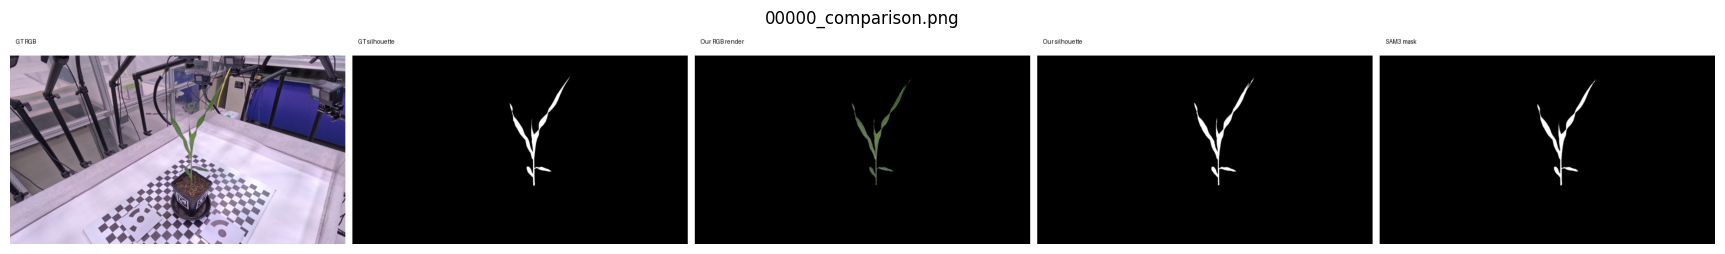

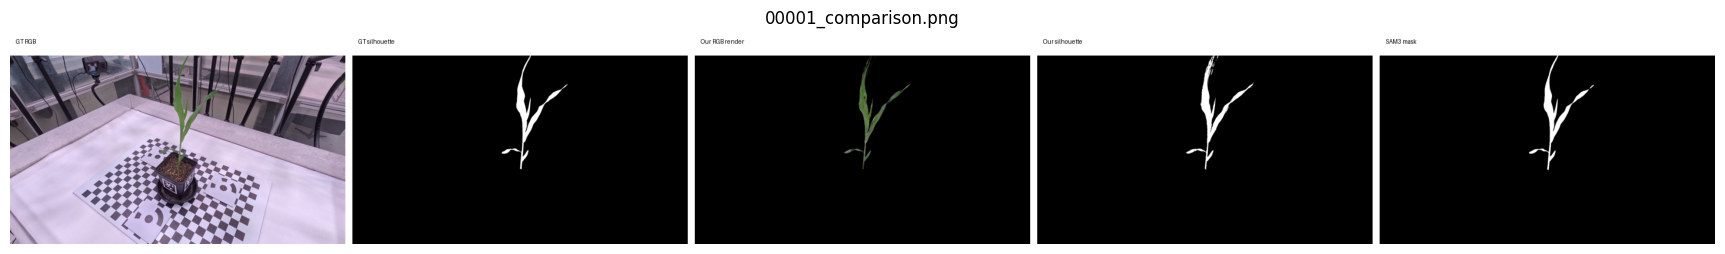

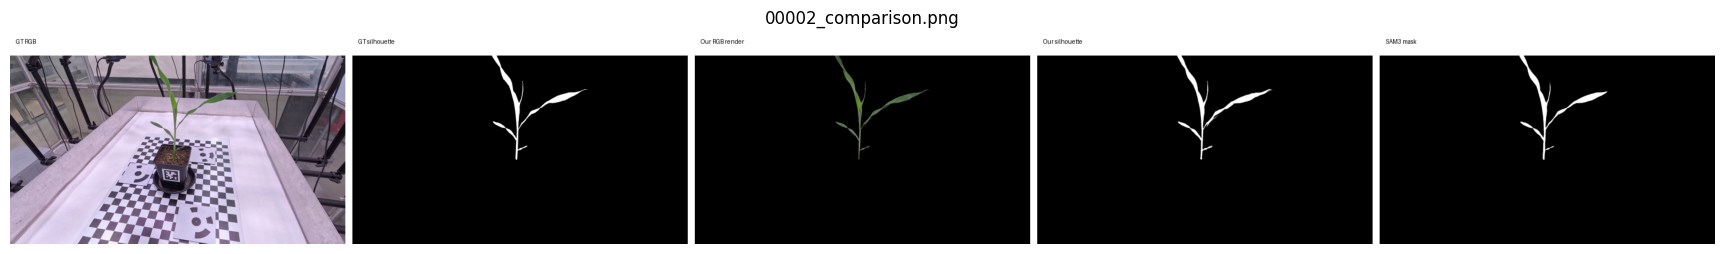

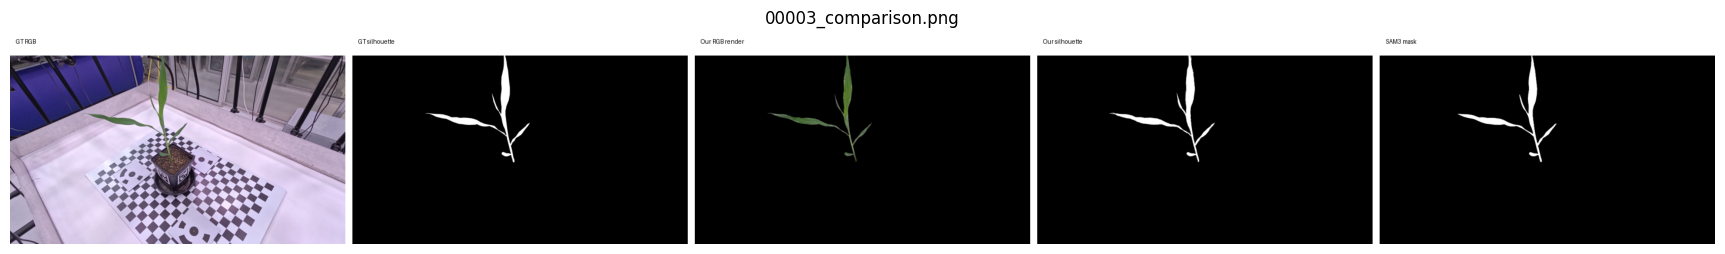

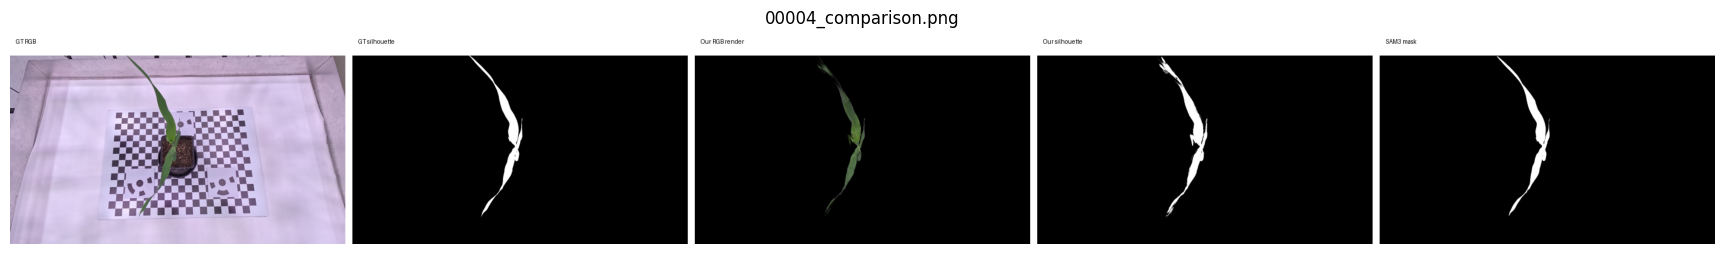

In [ ]:
import matplotlib.pyplot as plt

for p in panel_paths:
    img = np.array(Image.open(p).convert("RGB"))
    plt.figure(figsize=(22, 6))
    plt.imshow(img)
    plt.title(p.name)
    plt.axis("off")
    plt.show()

In [ ]:
%%bash
set -e
cd /content
ffmpeg -y -framerate 1 -i test_set_side_by_side_panels/%05d_comparison.png -pix_fmt yuv420p test_set_side_by_side_panels.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
%%bash
set -e
cd /content
zip -r test_set_side_by_side_panels.zip test_set_side_by_side_panels

  adding: test_set_side_by_side_panels/ (stored 0%)
  adding: test_set_side_by_side_panels/00004_comparison.png (deflated 2%)
  adding: test_set_side_by_side_panels/00002_comparison.png (deflated 2%)
  adding: test_set_side_by_side_panels/00000_comparison.png (deflated 2%)
  adding: test_set_side_by_side_panels/00001_comparison.png (deflated 2%)
  adding: test_set_side_by_side_panels/00003_comparison.png (deflated 2%)


In [ ]:
from google.colab import files

files.download("/content/test_set_side_by_side_panels.zip")
files.download("/content/test_set_side_by_side_panels.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluation paper loss alpha

In [ ]:
%%bash
set -e
cd /content

unzip -o frame_1180_paper_alpha.zip -d output_1180_paper_alpha_unzipped

Archive:  frame_1180_paper_alpha.zip
   creating: output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/
  inflating: output_1180_paper_alpha_unzipped/__MACOSX/._frame_1180_paper_alpha_loss  
   creating: output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/
  inflating: output_1180_paper_alpha_unzipped/__MACOSX/frame_1180_paper_alpha_loss/._frame_1180_paper_alpha_loss  
  inflating: output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/.DS_Store  
  inflating: output_1180_paper_alpha_unzipped/__MACOSX/frame_1180_paper_alpha_loss/._.DS_Store  
  inflating: output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/events.out.tfevents.1775143401.5ab9d4ef6dbe.15136.0  
  inflating: output_1180_paper_alpha_unzipped/__MACOSX/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/._events.out.tfevents.1775143401.5ab9d4ef6dbe.15136.0  
  inflating: output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/fra

In [ ]:
!find /content/output_1180_paper_alpha_unzipped -maxdepth 6 | sort | head -200

/content/output_1180_paper_alpha_unzipped
/content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss
/content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/.DS_Store
/content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss
/content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/cameras.json
/content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/cfg_args
/content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/chkpnt15000.pth
/content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/chkpnt7000.pth
/content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/.DS_Store
/content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/events.out.tfevents.1775143401.5ab9d4ef6dbe.15136.0
/conten

In [ ]:
from pathlib import Path

ITERATIONS = 15000

MODEL_DIR = Path("/content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss")

print("MODEL_DIR exists:", MODEL_DIR.exists())
print("cfg_args exists:", (MODEL_DIR / "cfg_args").exists())
print("checkpoint exists:", (MODEL_DIR / "chkpnt15000.pth").exists())
print("point cloud exists:", (MODEL_DIR / "point_cloud" / "iteration_15000" / "point_cloud.ply").exists())

MODEL_DIR exists: True
cfg_args exists: True
checkpoint exists: True
point cloud exists: True


In [ ]:
from pathlib import Path

RENDER_DIR = MODEL_DIR / f"test/ours_{ITERATIONS}/renders"
GT_DIR = MODEL_DIR / f"test/ours_{ITERATIONS}/gt"

IMG_DIR = Path("/content/data/frame_1180/images")
GT_MASK_DIR = Path("/content/data/frame_1180/masks_binary_gt")
SAM3_DIR = Path("/content/data/frame_1180/masks_sam3")

OUR_SIL_DIR = MODEL_DIR / f"test/ours_{ITERATIONS}/silhouettes_from_rgb"
OUR_SIL_DIR.mkdir(parents=True, exist_ok=True)

PANEL_DIR = Path("/content/paper_alpha_test_set_side_by_side_panels")
PANEL_DIR.mkdir(parents=True, exist_ok=True)

SEG_SAVE_DIR = Path("/content/paper_alpha_segmentation_metrics")
SEG_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("RENDER_DIR exists:", RENDER_DIR.exists())
print("GT_DIR exists:", GT_DIR.exists())
print("IMG_DIR exists:", IMG_DIR.exists())
print("GT_MASK_DIR exists:", GT_MASK_DIR.exists())
print("SAM3_DIR exists:", SAM3_DIR.exists())

RENDER_DIR exists: True
GT_DIR exists: True
IMG_DIR exists: True
GT_MASK_DIR exists: True
SAM3_DIR exists: True


In [ ]:
import sys
from argparse import ArgumentParser
import torch
from pathlib import Path

sys.path.insert(0, "/content/Wheat-3DGS")

from arguments import ModelParams
from scene import Scene
from scene.gaussian_model import GaussianModel

tmp_model = Path("/content/output/tmp_paper_alpha_debug")
tmp_model.mkdir(parents=True, exist_ok=True)

parser = ArgumentParser()
model = ModelParams(parser, sentinel=True)
args = parser.parse_args([])

args.source_path = "/content/data/frame_1180"
args.model_path = str(tmp_model)
args.images = "images"
args.eval = True
args.resolution = 4
args.data_device = "cuda" if torch.cuda.is_available() else "cpu"
args.white_background = False

gaussians = GaussianModel(3)
scene = Scene(args, gaussians, load_iteration=None, shuffle=False)

test_cams = scene.getTestCameras()
test_names = [cam.image_name for cam in test_cams]

print("Test camera order:")
for i, name in enumerate(test_names):
    print(i, name)

index_to_stem = {f"{i:05d}.png": stem for i, stem in enumerate(test_names)}
print("\nMapping:")
print(index_to_stem)

No directory of saved bounding boxes found!
No directory of saved segmentation masks found!
Reading camera 21/21
Train Cam list with 16 cams: ['GX010009_20250825_070502_1880_0', 'GX010030_20250825_070502_1880_1', 'GX010046_20250825_070502_1880_2', 'GX010051_20250825_070502_1880_3', 'GX010059_20250825_070502_1880_4', 'GX010062_20250825_070502_1880_5', 'GX010067_20250825_070502_1880_6', 'GX010068_20250825_070502_1880_7', 'GX010070_20250825_070502_1880_8', 'GX010078_20250825_070502_1880_9', 'GX010081_20250825_070502_1880_10', 'GX010089_20250825_070502_1880_11', 'GX010102_20250825_070502_1880_12', 'GX010127_20250825_070502_1880_13', 'GX010134_20250825_070502_1880_14', 'GX010141_20250825_070502_1880_15']
Test Cam list with 5 cams: ['GX010148_20250825_070503_1880_16', 'GX010156_20250825_070503_1880_17', 'GX010208_20250825_070502_1880_18', 'GX010279_20250825_070502_1880_19', 'GX010319_20250825_070502_1880_20']
Cameras extent: 0.5337348505909038
Loading Training Cameras


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Loading Test Cameras
Number of points at initialisation :  8433
Test camera order:
0 GX010148_20250825_070503_1880_16
1 GX010156_20250825_070503_1880_17
2 GX010208_20250825_070502_1880_18
3 GX010279_20250825_070502_1880_19
4 GX010319_20250825_070502_1880_20

Mapping:
{'00000.png': 'GX010148_20250825_070503_1880_16', '00001.png': 'GX010156_20250825_070503_1880_17', '00002.png': 'GX010208_20250825_070502_1880_18', '00003.png': 'GX010279_20250825_070502_1880_19', '00004.png': 'GX010319_20250825_070502_1880_20'}


In [ ]:
from PIL import Image
import numpy as np

threshold = 10  # foreground if max RGB > 10

files = sorted([p for p in RENDER_DIR.iterdir() if p.suffix.lower() == ".png"])

for p in files:
    img = np.array(Image.open(p).convert("RGB"))
    sil = (img.max(axis=2) > threshold).astype(np.uint8) * 255
    Image.fromarray(sil).save(OUR_SIL_DIR / p.name)

print("✅ Saved silhouettes to:", OUR_SIL_DIR)
print("Num files:", len(files))

✅ Saved silhouettes to: /content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/test/ours_15000/silhouettes_from_rgb
Num files: 5


In [ ]:
from PIL import Image, ImageDraw
import numpy as np
from pathlib import Path

def find_image_for_stem(stem: str):
    candidates = [
        IMG_DIR / f"{stem}.jpg",
        IMG_DIR / f"{stem}.jpeg",
        IMG_DIR / f"{stem}.png",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

def find_sam3_mask_for_stem(stem: str):
    candidates = [
        SAM3_DIR / f"{stem}.png",
        SAM3_DIR / f"{stem}_mask.png",
        SAM3_DIR / f"{stem}_sam3.png",
        SAM3_DIR / f"{stem}_mask_ground_truth.png",
    ]
    for p in candidates:
        if p.exists():
            return p
    matches = sorted(SAM3_DIR.glob(f"{stem}*.png"))
    if matches:
        return matches[0]
    return None

def load_binary_mask(path):
    arr = np.array(Image.open(path).convert("L"))
    return arr > 127

def mask_to_rgb(mask_bool):
    return Image.fromarray((mask_bool.astype(np.uint8) * 255)).convert("RGB")

def load_rgb(path):
    return Image.open(path).convert("RGB")

def resize_same_height(img, target_h=320):
    w, h = img.size
    new_w = int(round(w * target_h / h))
    return img.resize((new_w, target_h))

def add_title(img: Image.Image, title: str, title_h: int = 40):
    w, h = img.size
    canvas = Image.new("RGB", (w, h + title_h), color="white")
    canvas.paste(img, (0, title_h))
    draw = ImageDraw.Draw(canvas)
    draw.text((10, 10), title, fill="black")
    return canvas

def segmentation_metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    tn = np.logical_and(~pred, ~gt).sum()

    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else np.nan
    dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    return {
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        "iou": float(iou),
        "dice": float(dice),
        "precision": float(precision),
        "recall": float(recall),
    }

print("✅ Helpers ready")

✅ Helpers ready


In [ ]:
for render_name, stem in index_to_stem.items():
    img_path = find_image_for_stem(stem)
    gt_mask_path = GT_MASK_DIR / f"{stem}_mask_ground_truth.png"
    our_render_path = RENDER_DIR / render_name
    our_sil_path = OUR_SIL_DIR / render_name
    sam3_path = find_sam3_mask_for_stem(stem)

    print("\n", render_name, "->", stem)
    print("RGB       :", img_path)
    print("GT mask   :", gt_mask_path, gt_mask_path.exists())
    print("Our render:", our_render_path, our_render_path.exists())
    print("Our sil   :", our_sil_path, our_sil_path.exists())
    print("SAM3      :", sam3_path)


 00000.png -> GX010148_20250825_070503_1880_16
RGB       : /content/data/frame_1180/images/GX010148_20250825_070503_1880_16.jpg
GT mask   : /content/data/frame_1180/masks_binary_gt/GX010148_20250825_070503_1880_16_mask_ground_truth.png True
Our render: /content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/test/ours_15000/renders/00000.png True
Our sil   : /content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/test/ours_15000/silhouettes_from_rgb/00000.png True
SAM3      : /content/data/frame_1180/masks_sam3/GX010148_20250825_070503_1880_16_mask_sam3.png

 00001.png -> GX010156_20250825_070503_1880_17
RGB       : /content/data/frame_1180/images/GX010156_20250825_070503_1880_17.jpg
GT mask   : /content/data/frame_1180/masks_binary_gt/GX010156_20250825_070503_1880_17_mask_ground_truth.png True
Our render: /content/output_1180_paper_alpha_unzipped/frame_1180_paper_alpha_loss/frame_1180_paper_alpha_loss/

In [ ]:
import pandas as pd

rows = []

for render_name, stem in index_to_stem.items():
    pred_path = OUR_SIL_DIR / render_name
    gt_mask_path = GT_MASK_DIR / f"{stem}_mask_ground_truth.png"

    if not pred_path.exists():
        print("Missing predicted silhouette:", pred_path)
        continue
    if not gt_mask_path.exists():
        print("Missing GT mask:", gt_mask_path)
        continue

    pred = load_binary_mask(pred_path)
    gt = load_binary_mask(gt_mask_path)

    if pred.shape != gt.shape:
        print("Shape mismatch:", render_name, pred.shape, gt.shape)
        continue

    m = segmentation_metrics(pred, gt)
    rows.append({
        "file": render_name,
        "image_stem": stem,
        **m
    })

df_seg = pd.DataFrame(rows)
print("Computed rows:", len(df_seg))
display(df_seg)

Computed rows: 5


,file,image_stem,tp,fp,fn,tn,iou,dice,precision,recall
0,00000.png,GX010148_20250825_070503_1880_16,128028,11312,9463,15623997,0.860386,0.924954,0.918817,0.931174
1,00001.png,GX010156_20250825_070503_1880_17,175173,27904,8309,15561414,0.828688,0.906320,0.862594,0.954715
2,00002.png,GX010208_20250825_070502_1880_18,154494,14190,11262,15592854,0.858558,0.923897,0.915878,0.932057
3,00003.png,GX010279_20250825_070502_1880_19,207673,11147,8606,15545374,0.913145,0.954601,0.949059,0.960209
4,00004.png,GX010319_20250825_070502_1880_20,223572,29252,10809,15509167,0.848043,0.917774,0.884299,0.953883


In [ ]:
seg_summary = {
    "iou_mean": float(df_seg["iou"].mean()),
    "dice_mean": float(df_seg["dice"].mean()),
    "precision_mean": float(df_seg["precision"].mean()),
    "recall_mean": float(df_seg["recall"].mean()),
}

print("=== PAPER ALPHA SEGMENTATION SUMMARY ===")
for k, v in seg_summary.items():
    print(f"{k}: {v:.6f}")

=== PAPER ALPHA SEGMENTATION SUMMARY ===
iou_mean: 0.861764
dice_mean: 0.925509
precision_mean: 0.906129
recall_mean: 0.946407


In [ ]:
seg_summary = {
    "iou_mean": float(df_seg["iou"].mean()),
    "dice_mean": float(df_seg["dice"].mean()),
    "precision_mean": float(df_seg["precision"].mean()),
    "recall_mean": float(df_seg["recall"].mean()),
}

print("=== PAPER ALPHA SEGMENTATION SUMMARY ===")
for k, v in seg_summary.items():
    print(f"{k}: {v:.6f}")

=== PAPER ALPHA SEGMENTATION SUMMARY ===
iou_mean: 0.861764
dice_mean: 0.925509
precision_mean: 0.906129
recall_mean: 0.946407


In [ ]:
csv_path = SEG_SAVE_DIR / "per_image_segmentation_metrics.csv"
txt_path = SEG_SAVE_DIR / "summary_segmentation_metrics.txt"

df_seg.to_csv(csv_path, index=False)

with open(txt_path, "w") as f:
    f.write("Experiment: paper alpha loss\n")
    f.write(f"Model dir: {MODEL_DIR}\n")
    f.write(f"Iterations: {ITERATIONS}\n\n")
    f.write("Means\n")
    f.write("-----\n")
    for k, v in seg_summary.items():
        f.write(f"{k}: {v:.6f}\n")

print("✅ Saved:", csv_path)
print("✅ Saved:", txt_path)

✅ Saved: /content/paper_alpha_segmentation_metrics/per_image_segmentation_metrics.csv
✅ Saved: /content/paper_alpha_segmentation_metrics/summary_segmentation_metrics.txt


In [ ]:
from PIL import Image

panel_paths = []

for render_name, stem in index_to_stem.items():
    img_path = find_image_for_stem(stem)
    gt_mask_path = GT_MASK_DIR / f"{stem}_mask_ground_truth.png"
    our_render_path = RENDER_DIR / render_name
    our_sil_path = OUR_SIL_DIR / render_name
    sam3_path = find_sam3_mask_for_stem(stem)

    if img_path is None:
        print("Missing RGB image for", stem)
        continue
    if not gt_mask_path.exists():
        print("Missing GT mask for", stem)
        continue
    if not our_render_path.exists():
        print("Missing our render for", render_name)
        continue
    if not our_sil_path.exists():
        print("Missing our silhouette for", render_name)
        continue
    if sam3_path is None or not Path(sam3_path).exists():
        print("Missing SAM3 mask for", stem)
        continue

    gt_rgb = load_rgb(img_path)
    gt_mask = mask_to_rgb(load_binary_mask(gt_mask_path))
    our_rgb = load_rgb(our_render_path)
    our_sil = mask_to_rgb(load_binary_mask(our_sil_path))
    sam3_mask = mask_to_rgb(load_binary_mask(sam3_path))

    target_h = 320
    gt_rgb = resize_same_height(gt_rgb, target_h)
    gt_mask = resize_same_height(gt_mask, target_h)
    our_rgb = resize_same_height(our_rgb, target_h)
    our_sil = resize_same_height(our_sil, target_h)
    sam3_mask = resize_same_height(sam3_mask, target_h)

    gt_rgb = add_title(gt_rgb, "GT RGB")
    gt_mask = add_title(gt_mask, "GT silhouette")
    our_rgb = add_title(our_rgb, "Our RGB render")
    our_sil = add_title(our_sil, "Our silhouette")
    sam3_mask = add_title(sam3_mask, "SAM3 mask")

    gap = 12
    imgs = [gt_rgb, gt_mask, our_rgb, our_sil, sam3_mask]
    total_w = sum(im.size[0] for im in imgs) + gap * (len(imgs) - 1)
    total_h = max(im.size[1] for im in imgs)

    panel = Image.new("RGB", (total_w, total_h), color="white")

    x = 0
    for im in imgs:
        panel.paste(im, (x, 0))
        x += im.size[0] + gap

    out_path = PANEL_DIR / f"{render_name.replace('.png', '')}_comparison.png"
    panel.save(out_path)
    panel_paths.append(out_path)

    print("✅ Saved", out_path)

print("\nTotal panels saved:", len(panel_paths))

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


✅ Saved /content/paper_alpha_test_set_side_by_side_panels/00000_comparison.png
✅ Saved /content/paper_alpha_test_set_side_by_side_panels/00001_comparison.png
✅ Saved /content/paper_alpha_test_set_side_by_side_panels/00002_comparison.png
✅ Saved /content/paper_alpha_test_set_side_by_side_panels/00003_comparison.png
✅ Saved /content/paper_alpha_test_set_side_by_side_panels/00004_comparison.png

Total panels saved: 5


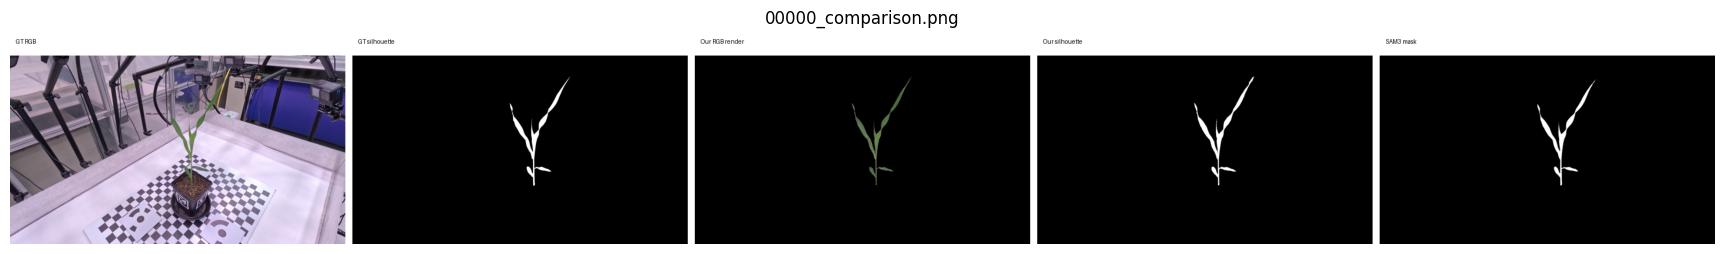

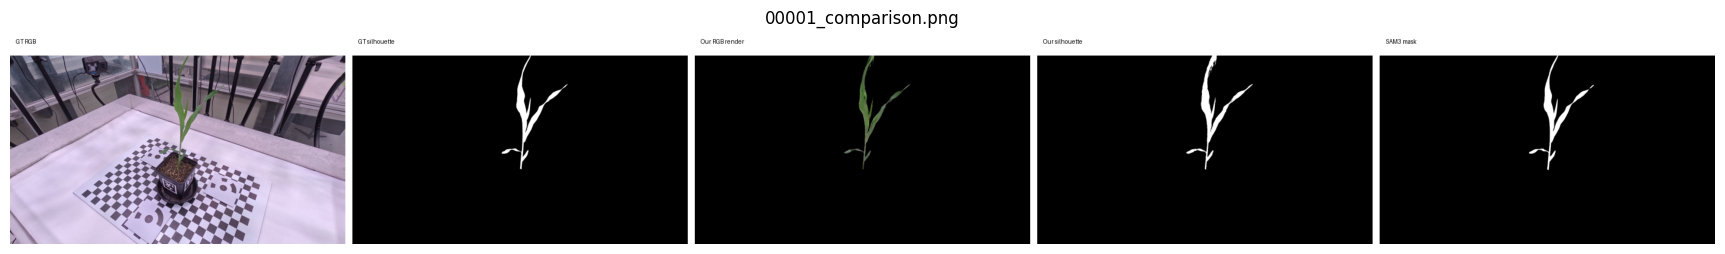

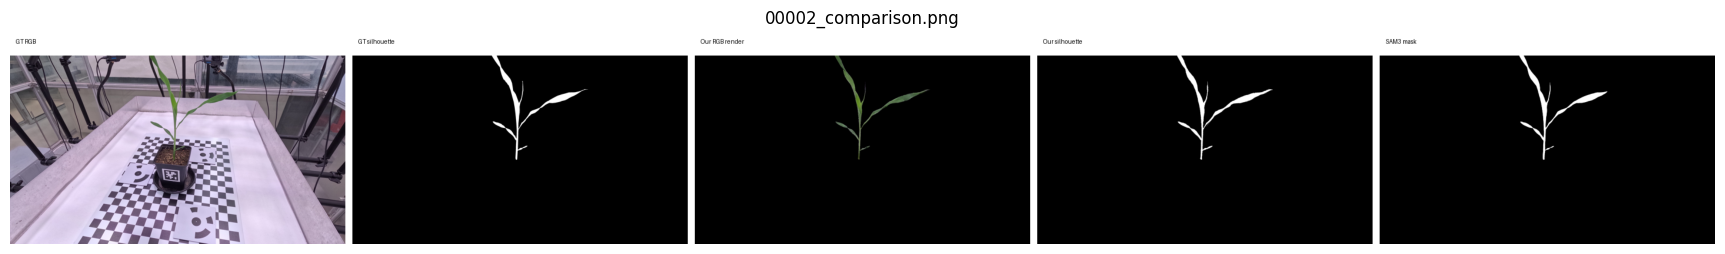

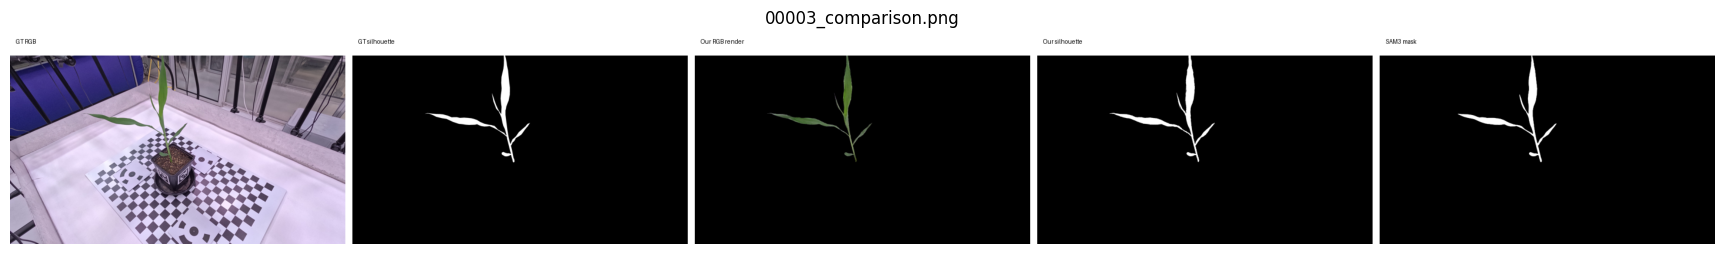

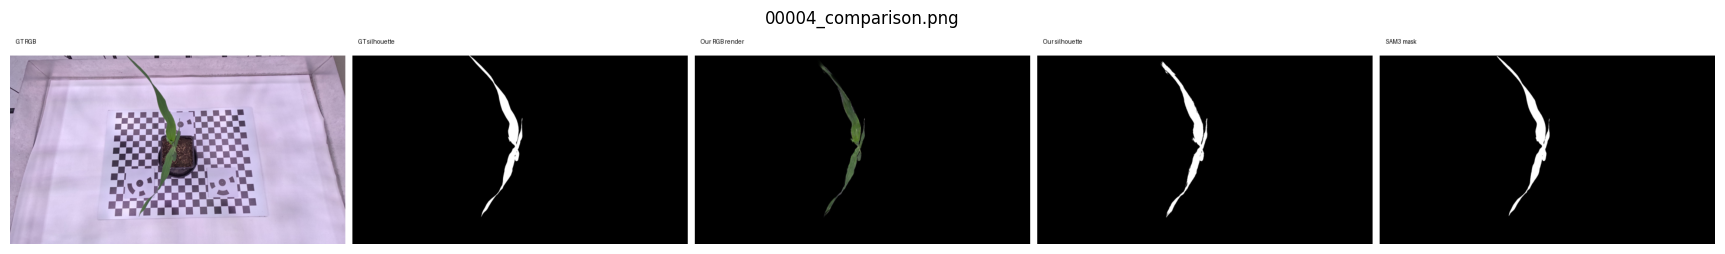

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for p in panel_paths:
    img = np.array(Image.open(p).convert("RGB"))
    plt.figure(figsize=(22, 6))
    plt.imshow(img)
    plt.title(p.name)
    plt.axis("off")
    plt.show()

In [ ]:
from pathlib import Path
import shutil

VIDEO_DIR = Path("/content/paper_alpha_test_set_side_by_side_panels_video")
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

for i, p in enumerate(sorted(panel_paths)):
    dst = VIDEO_DIR / f"{i:05d}.png"
    shutil.copy2(p, dst)

print("✅ Prepared video frames in", VIDEO_DIR)

✅ Prepared video frames in /content/paper_alpha_test_set_side_by_side_panels_video


In [ ]:
%%bash
set -e
cd /content
ffmpeg -y -framerate 1 -i paper_alpha_test_set_side_by_side_panels_video/%05d.png -pix_fmt yuv420p paper_alpha_test_set_side_by_side_panels.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
%%bash
set -e
cd /content
zip -r paper_alpha_test_set_side_by_side_panels.zip paper_alpha_test_set_side_by_side_panels
zip -r paper_alpha_segmentation_metrics.zip paper_alpha_segmentation_metrics

  adding: paper_alpha_test_set_side_by_side_panels/ (stored 0%)
  adding: paper_alpha_test_set_side_by_side_panels/00004_comparison.png (deflated 2%)
  adding: paper_alpha_test_set_side_by_side_panels/00002_comparison.png (deflated 2%)
  adding: paper_alpha_test_set_side_by_side_panels/00000_comparison.png (deflated 2%)
  adding: paper_alpha_test_set_side_by_side_panels/00001_comparison.png (deflated 2%)
  adding: paper_alpha_test_set_side_by_side_panels/00003_comparison.png (deflated 2%)
  adding: paper_alpha_segmentation_metrics/ (stored 0%)
  adding: paper_alpha_segmentation_metrics/per_image_segmentation_metrics.csv (deflated 50%)
  adding: paper_alpha_segmentation_metrics/summary_segmentation_metrics.txt (deflated 38%)


In [ ]:
from google.colab import files

files.download("/content/paper_alpha_test_set_side_by_side_panels.zip")
files.download("/content/paper_alpha_test_set_side_by_side_panels.mp4")
files.download("/content/paper_alpha_segmentation_metrics.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sys
from argparse import ArgumentParser
import torch
from pathlib import Path

sys.path.insert(0, "/content/Wheat-3DGS")

from arguments import ModelParams
from scene import Scene
from scene.gaussian_model import GaussianModel

tmp_model = Path("/content/output/tmp_paper_alpha_region_debug")
tmp_model.mkdir(parents=True, exist_ok=True)

parser = ArgumentParser()
model = ModelParams(parser, sentinel=True)
args = parser.parse_args([])

args.source_path = "/content/data/frame_1180"
args.model_path = str(tmp_model)
args.images = "images"
args.eval = True
args.resolution = 4
args.data_device = "cuda" if torch.cuda.is_available() else "cpu"
args.white_background = False

gaussians = GaussianModel(3)
scene = Scene(args, gaussians, load_iteration=None, shuffle=False)

test_cams = scene.getTestCameras()
test_names = [cam.image_name for cam in test_cams]

print("Test camera order:")
for i, name in enumerate(test_names):
    print(i, name)

index_to_stem = {f"{i:05d}.png": stem for i, stem in enumerate(test_names)}
print("\nMapping:")
print(index_to_stem)

No directory of saved bounding boxes found!
No directory of saved segmentation masks found!
Reading camera 21/21
Train Cam list with 16 cams: ['GX010009_20250825_070502_1880_0', 'GX010030_20250825_070502_1880_1', 'GX010046_20250825_070502_1880_2', 'GX010051_20250825_070502_1880_3', 'GX010059_20250825_070502_1880_4', 'GX010062_20250825_070502_1880_5', 'GX010067_20250825_070502_1880_6', 'GX010068_20250825_070502_1880_7', 'GX010070_20250825_070502_1880_8', 'GX010078_20250825_070502_1880_9', 'GX010081_20250825_070502_1880_10', 'GX010089_20250825_070502_1880_11', 'GX010102_20250825_070502_1880_12', 'GX010127_20250825_070502_1880_13', 'GX010134_20250825_070502_1880_14', 'GX010141_20250825_070502_1880_15']
Test Cam list with 5 cams: ['GX010148_20250825_070503_1880_16', 'GX010156_20250825_070503_1880_17', 'GX010208_20250825_070502_1880_18', 'GX010279_20250825_070502_1880_19', 'GX010319_20250825_070502_1880_20']
Cameras extent: 0.5337348505909038
Loading Training Cameras


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Loading Test Cameras
Number of points at initialisation :  8433
Test camera order:
0 GX010148_20250825_070503_1880_16
1 GX010156_20250825_070503_1880_17
2 GX010208_20250825_070502_1880_18
3 GX010279_20250825_070502_1880_19
4 GX010319_20250825_070502_1880_20

Mapping:
{'00000.png': 'GX010148_20250825_070503_1880_16', '00001.png': 'GX010156_20250825_070503_1880_17', '00002.png': 'GX010208_20250825_070502_1880_18', '00003.png': 'GX010279_20250825_070502_1880_19', '00004.png': 'GX010319_20250825_070502_1880_20'}


In [ ]:
import os
import math
import numpy as np
from pathlib import Path
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torch
import lpips

device = "cuda" if torch.cuda.is_available() else "cpu"
loss_fn = lpips.LPIPS(net="vgg").to(device)

def load_rgb(path):
    return np.array(Image.open(path).convert("RGB"))

def load_mask(path):
    m = np.array(Image.open(path).convert("L"))
    return (m > 127)

def bbox_from_mask(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x0, x1 = xs.min(), xs.max() + 1
    y0, y1 = ys.min(), ys.max() + 1
    return x0, y0, x1, y1

def crop_to_bbox(arr, bbox):
    x0, y0, x1, y1 = bbox
    if arr.ndim == 2:
        return arr[y0:y1, x0:x1]
    return arr[y0:y1, x0:x1, :]

def masked_psnr(gt, pred, mask):
    mask3 = np.repeat(mask[:, :, None], 3, axis=2)
    diff = gt.astype(np.float32) - pred.astype(np.float32)
    vals = diff[mask3]
    if vals.size == 0:
        return np.nan
    mse = np.mean(vals ** 2)
    if mse == 0:
        return float("inf")
    return 20.0 * math.log10(255.0) - 10.0 * math.log10(mse)

def masked_ssim(gt, pred, mask):
    gt_m = gt.copy()
    pred_m = pred.copy()
    gt_m[~mask] = 0
    pred_m[~mask] = 0
    return structural_similarity(gt_m, pred_m, channel_axis=2, data_range=255)

def lpips_from_arrays(a, b, size=512):
    a_pil = Image.fromarray(a).resize((size, size))
    b_pil = Image.fromarray(b).resize((size, size))

    a_t = torch.tensor(np.array(a_pil)).permute(2, 0, 1).float() / 127.5 - 1
    b_t = torch.tensor(np.array(b_pil)).permute(2, 0, 1).float() / 127.5 - 1

    a_t = a_t.unsqueeze(0).to(device)
    b_t = b_t.unsqueeze(0).to(device)

    with torch.no_grad():
        return loss_fn(a_t, b_t).item()

def masked_lpips(gt, pred, mask, size=512):
    gt_m = gt.copy()
    pred_m = pred.copy()
    gt_m[~mask] = 0
    pred_m[~mask] = 0
    return lpips_from_arrays(gt_m, pred_m, size=size)

print("✅ Metric helpers ready")

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
✅ Metric helpers ready


In [ ]:
import pandas as pd

render_files = sorted([f.name for f in RENDER_DIR.iterdir() if f.suffix.lower() == ".png"])
print("Number of render files:", len(render_files))

rows = []

for f in render_files:
    render_path = RENDER_DIR / f
    gt_path = GT_DIR / f

    if f not in index_to_stem:
        print("No mapping for:", f)
        continue

    stem = index_to_stem[f]
    mask_path = MASK_DIR / f"{stem}_mask_ground_truth.png"

    if not gt_path.exists():
        print("Missing GT:", gt_path)
        continue
    if not mask_path.exists():
        print("Missing mask:", mask_path)
        continue

    pred = load_rgb(render_path)
    gt = load_rgb(gt_path)
    mask = load_mask(mask_path)

    if pred.shape != gt.shape:
        print("Shape mismatch:", f, pred.shape, gt.shape)
        continue
    if mask.shape != gt.shape[:2]:
        print("Mask shape mismatch:", f, mask.shape, gt.shape[:2])
        continue

    bbox = bbox_from_mask(mask)
    if bbox is None:
        print("Empty mask:", f)
        continue

    # full image
    full_psnr = peak_signal_noise_ratio(gt, pred, data_range=255)
    full_ssim = structural_similarity(gt, pred, channel_axis=2, data_range=255)
    full_lpips = lpips_from_arrays(gt, pred)

    # plant only
    plant_psnr = masked_psnr(gt, pred, mask)
    plant_ssim = masked_ssim(gt, pred, mask)
    plant_lpips = masked_lpips(gt, pred, mask)

    # bbox
    gt_bbox = crop_to_bbox(gt, bbox)
    pred_bbox = crop_to_bbox(pred, bbox)

    bbox_psnr = peak_signal_noise_ratio(gt_bbox, pred_bbox, data_range=255)
    bbox_ssim = structural_similarity(gt_bbox, pred_bbox, channel_axis=2, data_range=255)
    bbox_lpips = lpips_from_arrays(gt_bbox, pred_bbox)

    rows.append({
        "file": f,
        "image_stem": stem,
        "mask_foreground_pixels": int(mask.sum()),
        "bbox_x0": bbox[0],
        "bbox_y0": bbox[1],
        "bbox_x1": bbox[2],
        "bbox_y1": bbox[3],
        "full_psnr": full_psnr,
        "full_ssim": full_ssim,
        "full_lpips": full_lpips,
        "plant_psnr": plant_psnr,
        "plant_ssim": plant_ssim,
        "plant_lpips": plant_lpips,
        "bbox_psnr": bbox_psnr,
        "bbox_ssim": bbox_ssim,
        "bbox_lpips": bbox_lpips,
    })

df_region = pd.DataFrame(rows)
print("Computed rows:", len(df_region))
display(df_region)

Number of render files: 5
Computed rows: 5


,file,image_stem,mask_foreground_pixels,bbox_x0,bbox_y0,bbox_x1,bbox_y1,full_psnr,full_ssim,full_lpips,plant_psnr,plant_ssim,plant_lpips,bbox_psnr,bbox_ssim,bbox_lpips
0,00000.png,GX010148_20250825_070503_1880_16,137491,2482,327,3442,2056,35.876374,0.993996,0.005037,15.851541,0.995140,0.004170,26.098059,0.942937,0.058565
1,00001.png,GX010156_20250825_070503_1880_17,183482,2359,0,3407,1796,34.684862,0.991129,0.009149,16.904154,0.993754,0.004782,25.454146,0.925523,0.079018
2,00002.png,GX010208_20250825_070502_1880_18,165756,2202,0,3728,1646,34.975937,0.992237,0.005665,15.890944,0.993601,0.003906,26.996696,0.951111,0.050695
3,00003.png,GX010279_20250825_070502_1880_19,216279,1147,0,2806,1688,34.673681,0.991921,0.005966,16.444204,0.992995,0.004669,27.167843,0.954425,0.044627
4,00004.png,GX010319_20250825_070502_1880_20,234381,1843,0,2686,2552,34.559172,0.989960,0.010920,17.304244,0.992867,0.007635,25.908444,0.926481,0.087664


In [ ]:
region_summary = {
    "full_psnr_mean": float(df_region["full_psnr"].mean()),
    "full_ssim_mean": float(df_region["full_ssim"].mean()),
    "full_lpips_mean": float(df_region["full_lpips"].mean()),

    "plant_psnr_mean": float(df_region["plant_psnr"].mean()),
    "plant_ssim_mean": float(df_region["plant_ssim"].mean()),
    "plant_lpips_mean": float(df_region["plant_lpips"].mean()),

    "bbox_psnr_mean": float(df_region["bbox_psnr"].mean()),
    "bbox_ssim_mean": float(df_region["bbox_ssim"].mean()),
    "bbox_lpips_mean": float(df_region["bbox_lpips"].mean()),
}

print("=== PAPER ALPHA REGION METRICS SUMMARY ===")
for k, v in region_summary.items():
    print(f"{k}: {v:.6f}")

=== PAPER ALPHA REGION METRICS SUMMARY ===
full_psnr_mean: 34.954005
full_ssim_mean: 0.991849
full_lpips_mean: 0.007347
plant_psnr_mean: 16.479017
plant_ssim_mean: 0.993671
plant_lpips_mean: 0.005032
bbox_psnr_mean: 26.325037
bbox_ssim_mean: 0.940095
bbox_lpips_mean: 0.064114
